In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df=pd.read_csv("/content/drive/MyDrive/Projects /CREDIT RISK MODELLING/loan2 (2).csv")

In [ ]:
pd.set_option("display.max_rows",None)
pd.set_option("display.max_columns",None)

In [ ]:
defaultdf=df[df['default']==1]
nondefdf=df[df['default']==0]

In [ ]:
df.drop(columns=['Unnamed: 0'],inplace=True)

In [ ]:
defaultdf.shape

(55332, 42)

### NOW FEATURES

In [ ]:
df['loan_to_income']=df['loan_amnt'] / df['annual_inc']

In [ ]:
today=datetime.today()
today

datetime.datetime(2025, 7, 24, 11, 58, 55, 9548)

In [ ]:
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'])
df['issue_d'] = pd.to_datetime(df['issue_d'],format='%b-%y')
df['last_pymnt_d'] = pd.to_datetime(df['last_pymnt_d'],format='%b-%y')
df['last_credit_pull_d'] = pd.to_datetime(df['last_credit_pull_d'],format='%b-%y')

In [ ]:
df['credit_age'] = round((today-df['earliest_cr_line']).dt.days/365)

In [ ]:
df['credit_age'].sample()

,credit_age
78903,24.0


In [ ]:
df[df['credit_age']<0].sample(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age
185045,28000,28000,60,23.76,801.61,F,expeditors international,6,MORTGAGE,80000.0,Verified,2012-11-01,Fully Paid,debt_consolidation,AZ,22.28,1.0,2066-07-01,0.0,9.0,0.0,6330,48.3,26.0,f,0.00,35751.83013,28000.00,7751.83,0.0,0.0,0.0,2014-02-01,24534.54,2016-01-01,0.0,0.0,178.0,271903.0,13100.0,0,0.350000,-41.0
465496,2500,2500,36,19.22,91.92,D,unknown,0,MORTGAGE,34908.0,Source Verified,2014-01-01,Charged Off,major_purchase,AL,16.71,0.0,2067-09-01,1.0,9.0,0.0,8660,84.1,17.0,f,0.00,1654.43000,1072.41,582.02,0.0,0.0,0.0,2015-07-01,91.92,2015-09-01,0.0,0.0,0.0,18962.0,10300.0,1,0.071617,-42.0
294475,32100,32100,60,18.99,832.52,E,unknown,0,MORTGAGE,70000.0,Verified,2014-10-01,Late (16-30 days),debt_consolidation,MO,17.38,1.0,2064-01-01,0.0,6.0,0.0,30328,87.9,18.0,w,27058.20,11655.28000,5041.80,6613.48,0.0,0.0,0.0,2015-12-01,832.52,2016-01-01,0.0,0.0,0.0,47619.0,34500.0,1,0.458571,-38.0
233109,9650,9650,36,14.99,334.48,C,unknown,0,OWN,32264.0,Verified,2014-12-01,Current,credit_card,VA,11.42,0.0,2068-02-01,3.0,6.0,0.0,6942,76.3,17.0,f,6898.85,4007.21000,2751.15,1256.06,0.0,0.0,0.0,2015-12-01,334.48,2016-01-01,0.0,0.0,0.0,7954.0,9100.0,0,0.299095,-43.0
234108,7600,7600,36,11.44,250.41,B,president,10,MORTGAGE,110000.0,Not Verified,2014-12-01,Current,debt_consolidation,MI,20.00,1.0,2067-06-01,0.0,7.0,0.0,30552,68.3,19.0,f,5149.50,3250.50000,2450.50,800.00,0.0,0.0,0.0,2016-01-01,250.41,2016-01-01,0.0,0.0,0.0,238799.0,44700.0,0,0.069091,-42.0


we have a lot of data errors for earliest_cr_line, we will replace all the dates with today.

In [ ]:
tod=pd.to_datetime('today').normalize()
tod

Timestamp('2025-07-24 00:00:00')

In [ ]:
df['earliest_cr_line']=df['earliest_cr_line'].apply(lambda x : tod if x > tod or pd.isna(x) else x)

In [ ]:
df['credit_age'] = round((today-df['earliest_cr_line']).dt.days/365)

In [ ]:
df[df['credit_age']<0]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466281 entries, 0 to 466280
Data columns (total 43 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   loan_amnt                   466281 non-null  int64         
 1   funded_amnt                 466281 non-null  int64         
 2   term                        466281 non-null  int64         
 3   int_rate                    466281 non-null  float64       
 4   installment                 466281 non-null  float64       
 5   grade                       466281 non-null  object        
 6   emp_title                   466281 non-null  object        
 7   emp_length                  466281 non-null  int64         
 8   home_ownership              466281 non-null  object        
 9   annual_inc                  466281 non-null  float64       
 10  verification_status         466281 non-null  object        
 11  issue_d                     466281 non-

In [ ]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age
0,5000,5000,36,10.65,162.87,B,unknown,10,RENT,24000.0,Verified,2011-12-01,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,5861.071414,5000.00,861.07,0.00,0.00,0.00,2015-01-01,171.62,2016-01-01,0.0,0.0,NaN,NaN,NaN,0,0.208333,41.0
1,2500,2500,60,15.27,59.83,C,ryder,0,RENT,30000.0,Source Verified,2011-12-01,Charged Off,car,GA,1.00,0.0,1999-04-01,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,1008.710000,456.46,435.17,0.00,117.08,1.11,2013-04-01,119.66,2013-09-01,0.0,0.0,NaN,NaN,NaN,1,0.083333,26.0
2,2400,2400,36,15.96,84.33,C,unknown,10,RENT,12252.0,Not Verified,2011-12-01,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,3003.653644,2400.00,603.65,0.00,0.00,0.00,2014-06-01,649.91,2016-01-01,0.0,0.0,NaN,NaN,NaN,0,0.195886,24.0
3,10000,10000,36,13.49,339.31,C,air resources board,10,RENT,49200.0,Source Verified,2011-12-01,Fully Paid,other,CA,20.00,0.0,1996-02-01,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,12226.302210,10000.00,2209.33,16.97,0.00,0.00,2015-01-01,357.48,2015-01-01,0.0,0.0,NaN,NaN,NaN,0,0.203252,29.0
4,3000,3000,60,12.69,67.79,B,university medical group,1,RENT,80000.0,Source Verified,2011-12-01,Current,other,OR,17.94,0.0,1996-01-01,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,3242.170000,2233.10,1009.07,0.00,0.00,0.00,2016-01-01,67.79,2016-01-01,0.0,0.0,NaN,NaN,NaN,0,0.037500,30.0


In [ ]:
cat_col=df.select_dtypes(include=['object']).columns.tolist()
cat_col

['grade',
 'emp_title',
 'home_ownership',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'initial_list_status']

In [ ]:
num_col=df.select_dtypes(include=['int64','float64']).columns.tolist()
num_col

['loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'total_pymnt',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'default',
 'loan_to_income',
 'credit_age']

In [ ]:
corr=round(df[num_col].corr(),2)
corr

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age
loan_amnt,1.00,1.00,0.41,0.17,0.95,0.14,0.37,0.06,0.01,-0.02,0.20,-0.08,0.33,0.12,0.24,0.52,0.74,0.61,0.72,0.04,0.11,0.08,0.30,-0.01,0.01,-0.00,0.33,0.29,0.02,0.56,0.17
funded_amnt,1.00,1.00,0.41,0.17,0.95,0.14,0.37,0.06,0.01,-0.02,0.20,-0.08,0.33,0.12,0.24,0.52,0.74,0.61,0.72,0.04,0.11,0.08,0.30,-0.01,0.01,-0.00,0.33,0.29,0.02,0.56,0.17
term,0.41,0.41,1.00,0.44,0.16,0.09,0.07,0.09,0.00,0.01,0.08,-0.02,0.09,0.08,0.10,0.43,0.17,0.01,0.53,0.01,0.09,0.06,0.11,0.00,0.01,-0.00,0.12,0.06,0.07,0.34,0.06
int_rate,0.17,0.17,0.44,1.00,0.15,0.03,-0.05,0.16,0.08,0.21,0.01,0.07,-0.00,0.32,-0.03,0.14,0.13,-0.03,0.49,0.06,0.13,0.08,0.08,0.02,0.03,0.00,-0.10,-0.15,0.18,0.22,-0.09
installment,0.95,0.95,0.16,0.15,1.00,0.12,0.37,0.05,0.02,0.00,0.20,-0.07,0.32,0.14,0.22,0.41,0.76,0.66,0.64,0.05,0.11,0.08,0.30,-0.01,0.01,-0.00,0.30,0.27,0.02,0.52,0.15
emp_length,0.14,0.14,0.09,0.03,0.12,1.00,0.10,0.03,0.03,-0.01,0.06,0.02,0.10,0.05,0.11,0.09,0.10,0.08,0.11,-0.01,0.01,0.01,0.05,-0.00,0.01,-0.00,0.11,0.07,-0.02,0.00,0.16
annual_inc,0.37,0.37,0.07,-0.05,0.37,0.10,1.00,-0.19,0.06,0.06,0.16,-0.02,0.33,0.04,0.22,0.17,0.30,0.28,0.21,0.02,0.02,0.01,0.14,-0.00,0.02,0.00,0.49,0.29,-0.05,-0.28,0.17
dti,0.06,0.06,0.09,0.16,0.05,0.03,-0.19,1.00,-0.00,-0.01,0.30,-0.05,0.14,0.20,0.23,0.12,-0.03,-0.06,0.09,-0.01,0.02,0.02,-0.04,0.00,0.01,-0.00,-0.02,0.06,0.05,0.26,0.03
delinq_2yrs,0.01,0.01,0.00,0.08,0.02,0.03,0.06,-0.00,1.00,0.02,0.06,-0.01,-0.03,-0.01,0.13,0.04,-0.02,-0.03,0.02,0.02,0.00,0.01,-0.01,0.04,0.13,0.00,0.07,-0.04,0.01,-0.06,0.09
inq_last_6mths,-0.02,-0.02,0.01,0.21,0.00,-0.01,0.06,-0.01,0.02,1.00,0.09,0.04,-0.02,-0.09,0.12,-0.07,0.02,0.01,0.04,0.03,0.04,0.03,0.04,-0.00,-0.01,0.00,0.06,0.01,0.07,-0.09,0.00


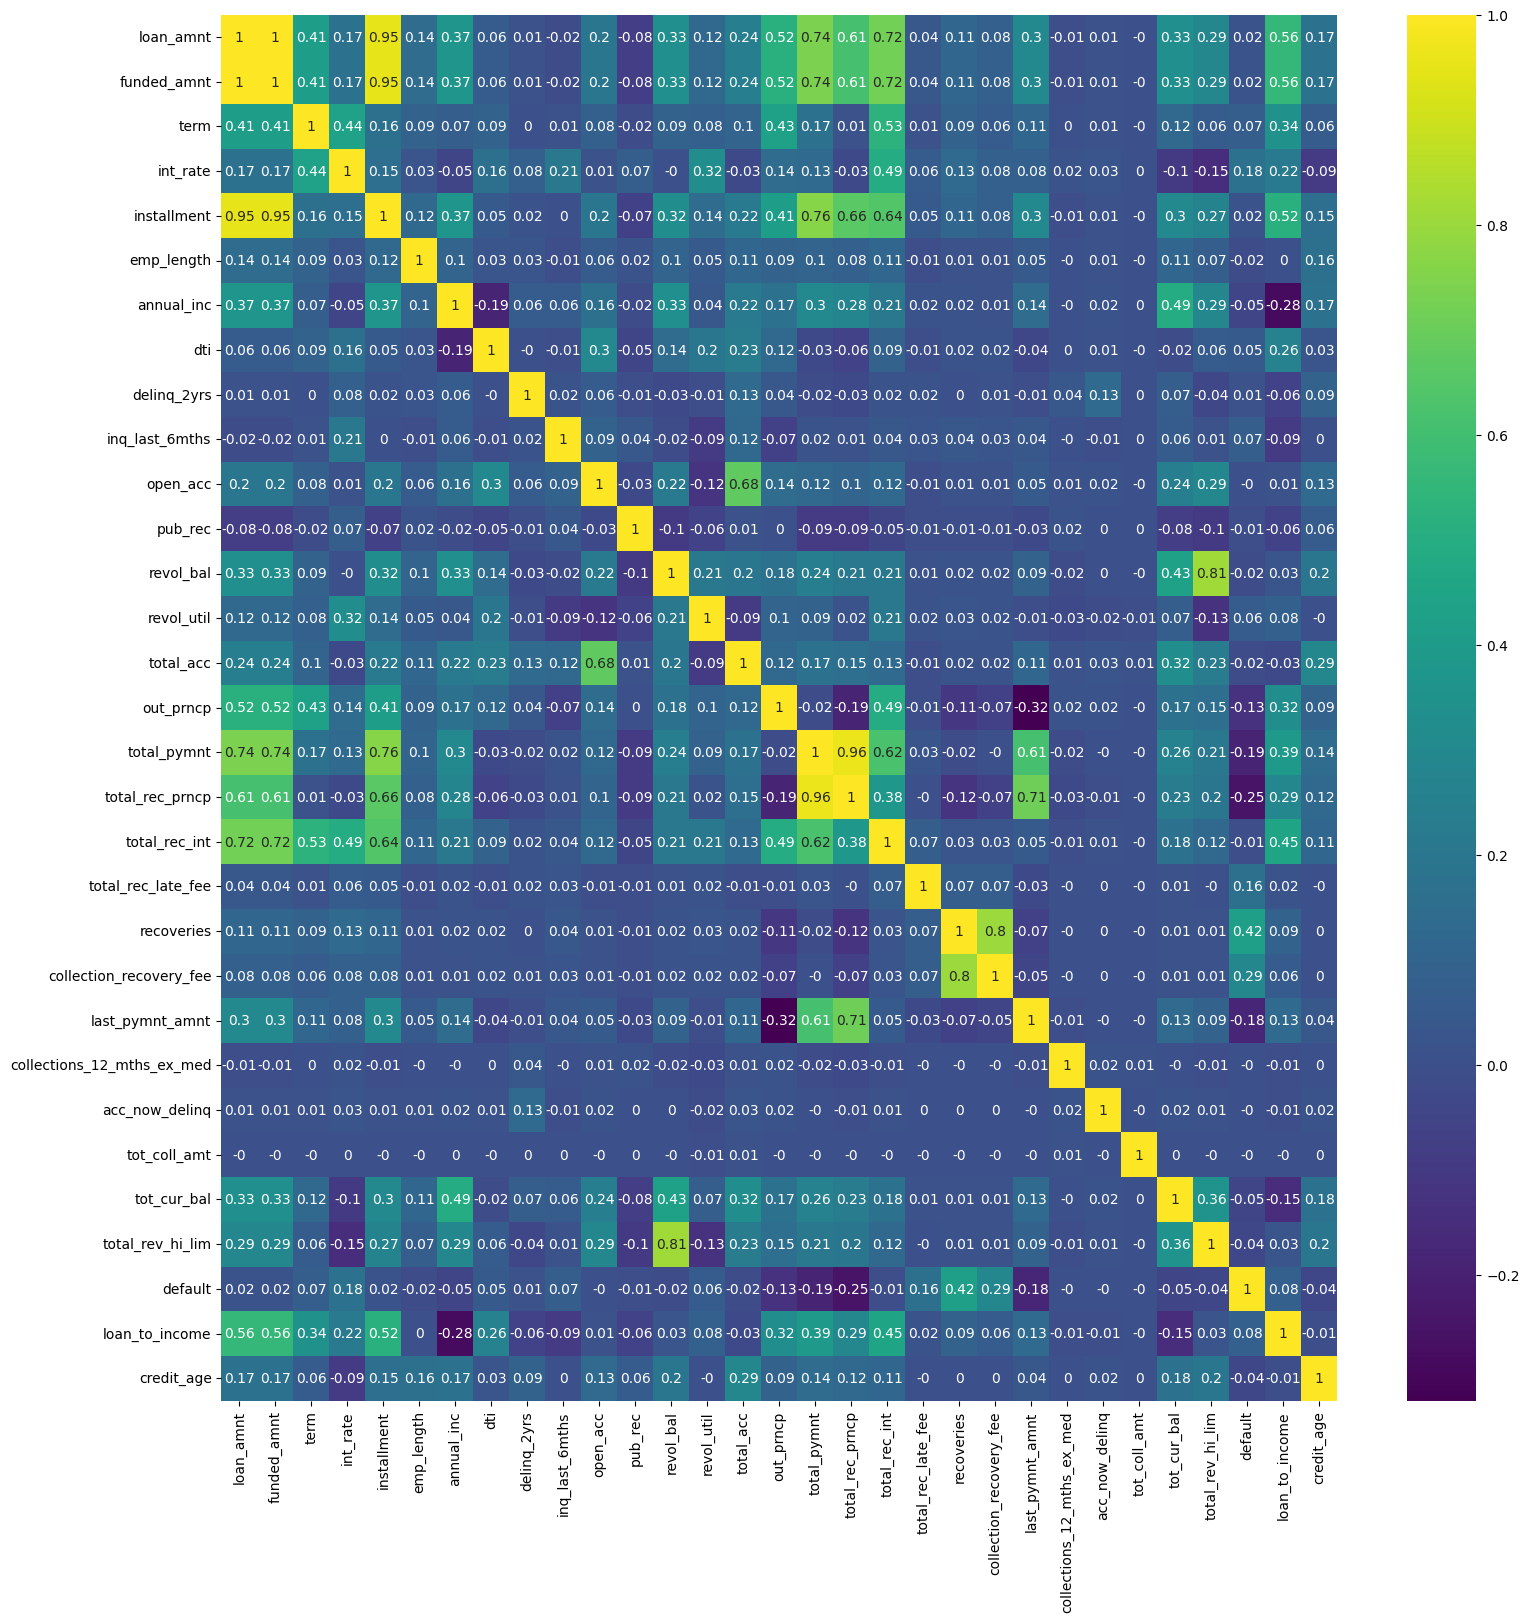

In [ ]:
plt.figure(figsize=(18,18))
sns.heatmap(corr,annot=True,cmap='viridis')
plt.show()

In [ ]:
df.groupby(by='default')[num_col].agg(['mean','std','median'])

loan_amnt                         funded_amnt               \
                 mean          std   median          mean          std   
default                                                                  
0        14264.420098  8268.741720  12000.0  14241.113861  8257.914577   
1        14710.427962  8406.965249  13000.0  14668.830875  8386.070461   

                       term                     int_rate                   \
          median       mean        std median       mean       std median   
default                                                                     
0        12000.0  42.339940  10.581304   36.0  13.541762  4.289741  13.35   
1        12975.0  44.576881  11.501506   36.0  15.964733  4.262725  15.61   

        installment                      emp_length                   \
               mean         std   median       mean       std median   
default                                                                
0        430.307947  242.962059  377.410   5.750950  3.754944    6.0   
1        445.099555  246.951438  394.175   5.518416  3.758064    6.0   

           annual_inc                               dti                   \
                 mean           std   median       mean       std median   
default                                                                    
0        74244.521606  56412.964133  64000.0  17.068919  7.836249  16.68   
1        66094.462513  41994.786217  57000.0  18.332722  7.871043  18.30   

        delinq_2yrs                  inq_last_6mths                   \
               mean       std median           mean       std median   
default                                                                
0          0.282845  0.792475    0.0       0.775994  1.063367    0.0   
1          0.298164  0.832515    0.0       1.018273  1.261633    1.0   

          open_acc                    pub_rec                      revol_bal  \
              mean       std median      mean       std median          mean   
default                                                                        
0        11.192394  4.987630   10.0  0.161895  0.518116    0.0  16371.433791   
1        11.147518  4.986625   10.0  0.150680  0.453259    0.0  15182.463818   

                               revol_util                    total_acc  \
                  std   median       mean        std median       mean   
default                                                                  
0        20904.670133  11827.0  55.695833  23.753429   57.0  25.153796   
1        18861.003339  11337.5  59.751720  23.268202   61.7  24.400712   

                             out_prncp                         total_pymnt  \
               std median         mean          std   median          mean   
default                                                                      
0        11.594866   24.0  4714.051468  6433.770006  1497.63  12121.583987   
1        11.617854   23.0  2152.663603  5208.895978     0.00   7226.698673   

                                total_rec_prncp                         \
                 std     median            mean          std    median   
default                                                                  
0        8374.515224  10049.270     9521.804409  7114.584274  7500.000   
1        5809.561045   5658.395     3995.670577  3718.099039  2913.175   

        total_rec_int                       total_rec_late_fee             \
                 mean          std   median               mean        std   
default                                                                     
0         2599.439762  2481.182292  1832.32           0.339820   3.677227   
1         2508.874142  2501.857270  1716.18           2.954834  11.278828   

                recoveries                     collection_recovery_fee  \
        median        mean          std median                    mean   
default                                                                  
0         

In [ ]:
df.describe()

,loan_amnt,funded_amnt,term,int_rate,installment,emp_length,annual_inc,issue_d,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age
count,466281.000000,466281.000000,466281.000000,466281.000000,466281.000000,466281.000000,4.662810e+05,466281,466281.000000,466281.000000,466281,466256.000000,466256.000000,466256.000000,4.662810e+05,465945.000000,466256.000000,466281.000000,466281.000000,466281.000000,466281.000000,466281.000000,466281.000000,466281.000000,465905,466281.000000,466239,466140.000000,466256.000000,3.960090e+05,3.960090e+05,3.960090e+05,466281.000000,466281.000000,466281.000000
mean,14317.346353,14291.869602,42.605390,13.829287,432.063217,5.723356,7.327738e+04,2013-08-23 16:01:08.003629056,17.218891,0.284663,1997-11-10 11:29:50.862591488,0.804745,11.187069,0.160564,1.623034e+04,56.176947,25.064430,4410.100174,11540.724389,8866.036670,2588.692644,0.650135,85.344943,8.961611,2015-04-23 05:27:25.914081280,3123.938895,2015-08-30 17:33:45.537117440,0.009085,0.004002,1.919135e+02,1.388017e+05,3.037909e+04,0.118667,0.218683,27.706059
min,500.000000,500.000000,36.000000,5.420000,15.670000,0.000000,1.896000e+03,2007-06-01 00:00:00,0.000000,0.000000,1969-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2007-12-01 00:00:00,0.000000,2007-05-01 00:00:00,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000789,0.000000
25%,8000.000000,8000.000000,36.000000,10.990000,256.700000,2.000000,4.500000e+04,2013-03-01 00:00:00,11.360000,0.000000,1994-03-01 00:00:00,0.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,5552.120000,3708.560000,957.330000,0.000000,0.000000,0.000000,2015-01-01 00:00:00,312.620000,2015-11-01 00:00:00,0.000000,0.000000,0.000000e+00,2.861800e+04,1.350000e+04,0.000000,0.131579,23.000000
50%,12000.000000,12000.000000,36.000000,13.660000,379.890000,6.000000,6.300000e+04,2014-01-01 00:00:00,16.870000,0.000000,1999-03-01 00:00:00,0.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.770000,9419.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,2015-12-01 00:00:00,545.960000,2016-01-01 00:00:00,0.000000,0.000000,0.000000e+00,8.153900e+04,2.280000e+04,0.000000,0.205714,26.000000
75%,20000.000000,20000.000000,60.000000,16.490000,566.580000,10.000000,8.896000e+04,2014-07-01 00:00:00,22.780000,0.000000,2002-09-01 00:00:00,1.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,15308.330220,12000.000000,3304.540000,0.000000,0.000000,0.000000,2016-01-01 00:00:00,3187.910000,2016-01-01 00:00:00,0.000000,0.000000,0.000000e+00,2.089530e+05,3.790000e+04,0.000000,0.298507,31.000000
max,35000.000000,35000.000000,60.000000,26.060000,1409.990000,10.000000,7.500000e+06,2014-12-01 00:00:00,39.990000,29.000000,2025-07-24 00:00:00,33.000000,84.000000,63.000000,2.568995e+06,892.300000,156.000000,32160.380000,57777.579870,35000.030000,24205.620000,358.680000,33520.270000,7002.190000,2016-01-01 00:00:00,36234.440000,2016-01-01 00:00:00,20.000000,5.000000,9.152545e+06,8.000078e+06,9.999999e+06,1.000000,1.337500,57.000000
std,8286.511128,8274.373374,10.719069,4.357570,243.485610,3.756063,5.496357e+04,NaN,7.851023,0.797346,NaN,1.091598,4.987526,0.510863,2.067628e+04,23.732628,11.600141,6355.092901,8265.651888,7031.713779,2483.814713,5.265752,552.218396,85.491800,NaN,5554.754608,NaN,0.108648,0.068637,1.463021e+04,1.521147e+05,3.724713e+04,0.323396,0.110894,7.215862


In [ ]:
df.sample()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age
336857,25450,25450,36,12.49,851.28,B,president,10,MORTGAGE,300000.0,Not Verified,2014-07-01,Current,debt_consolidation,MI,20.96,0.0,1995-07-01,1.0,20.0,0.0,62742,70.3,44.0,w,14606.54,14471.76,10843.46,3628.3,0.0,0.0,0.0,2016-01-01,851.28,2016-01-01,0.0,0.0,0.0,536782.0,89300.0,0,0.084833,30.0


In [ ]:
df[['loan_amnt','default']].describe()

,loan_amnt,default
count,466281.000000,466281.000000
mean,14317.346353,0.118667
std,8286.511128,0.323396
min,500.000000,0.000000
25%,8000.000000,0.000000
50%,12000.000000,0.000000
75%,20000.000000,0.000000
max,35000.000000,1.000000


<Axes: xlabel='default', ylabel='loan_amnt'>

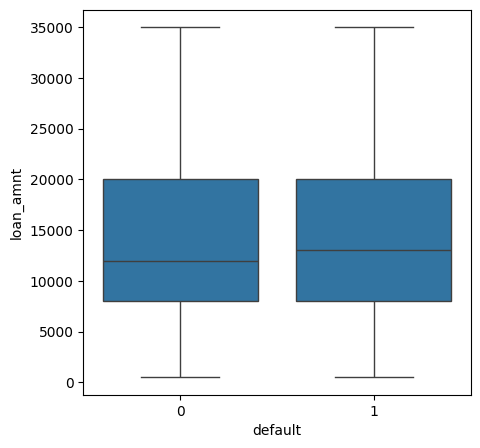

In [ ]:
#boxplot between target and loan amnt - not much of a difference
plt.figure(figsize=(5,5))
sns.boxplot(y=df['loan_amnt'],x=df['default'])

<Axes: xlabel='count', ylabel='purpose'>

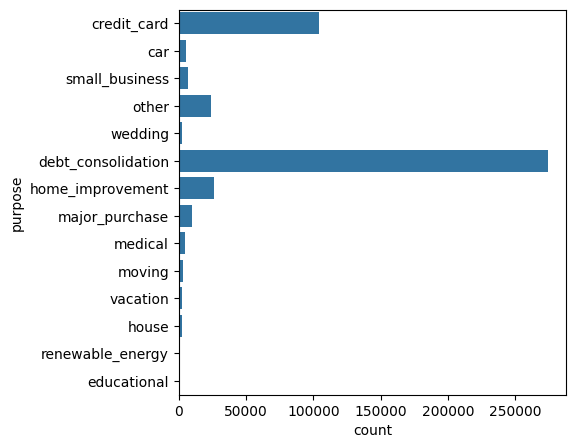

In [ ]:
#purpose vs defaulter
plt.figure(figsize=(5,5))
sns.countplot(y=df['purpose'])

<Axes: xlabel='count', ylabel='purpose'>

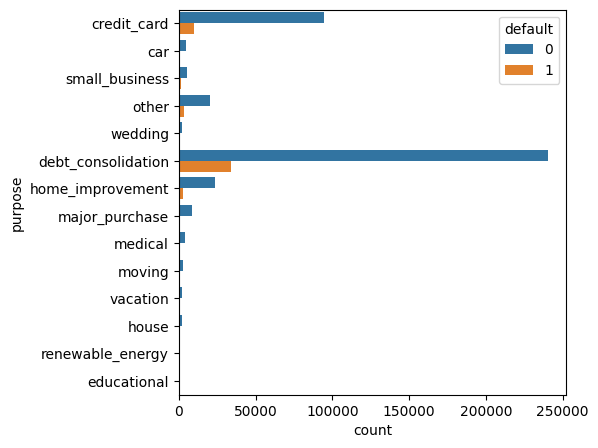

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(y=df['purpose'],hue=df['default'])

In [ ]:
df.groupby(by=['grade'])['default']

<Axes: xlabel='grade'>

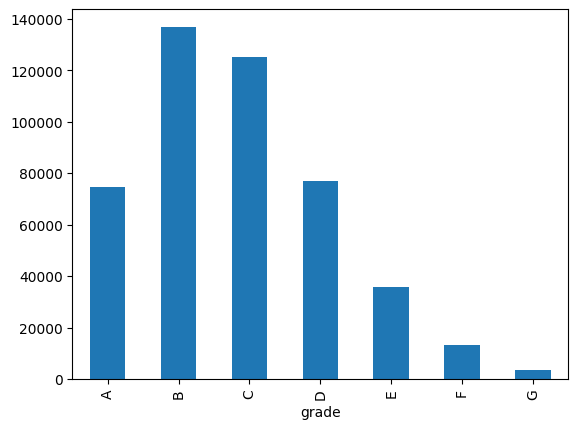

In [ ]:
df.groupby(by=['grade'])['default'].count().plot(kind='bar')


In [ ]:
# to check statewise defaulter
defaultdf['addr_state'].value_counts()

,count
addr_state,
CA,8698
NY,5173
FL,4256
TX,3827
NJ,2264
PA,1988
IL,1901
VA,1768
OH,1760


<Axes: xlabel='addr_state'>

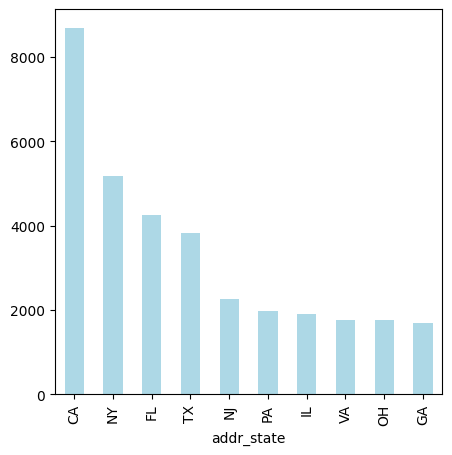

In [ ]:
plt.figure(figsize=(5,5))
defaultdf['addr_state'].value_counts().head(10).plot(kind='bar',color='lightblue')

<Axes: xlabel='grade', ylabel='purpose'>

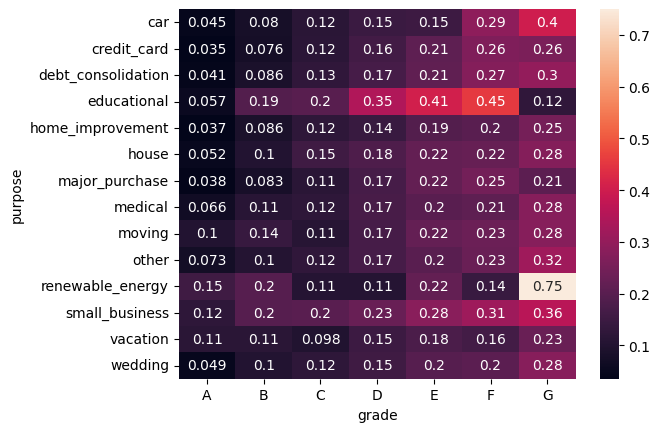

In [ ]:
# interaction of categorical features --- loan purpose vs grade vs default

pivot = df.pivot_table(index='purpose',columns='grade',values='default',aggfunc='mean')
sns.heatmap(pivot,annot=True)

### CONCLUSION
1. average default rate is very high for grade G corresponding to renewable energy
2. loans for educational and small business purpose are comparatively very high.
3. it is very evident that the average default rate for the groups E F G are very high.

In [ ]:
# employment_title vs default
top=defaultdf['emp_title'].value_counts().head(8)
top

,count
emp_title,
unknown,4036
manager,722
teacher,547
supervisor,336
driver,318
registered nurse,294
sales,280
owner,249


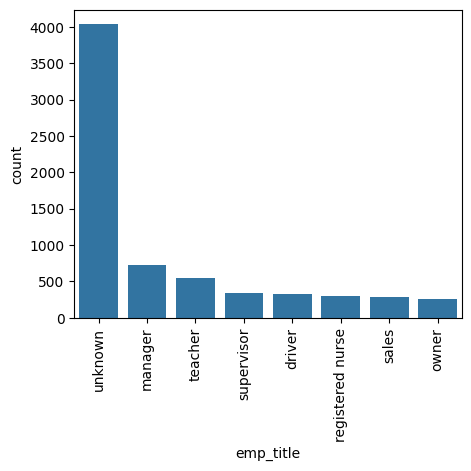

In [ ]:
plt.figure(figsize=(5,4))
sns.barplot(top)
plt.xticks(rotation=90)
plt.show()

In [ ]:
#home ownership
hown=defaultdf['home_ownership'].value_counts()

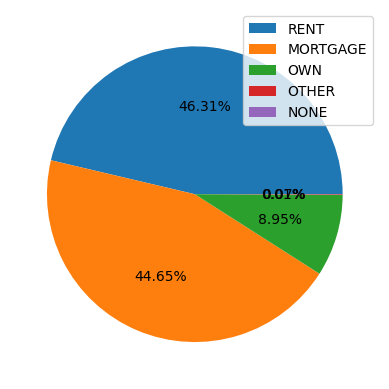

In [ ]:
plt.pie(hown,autopct='%0.2f%%')
plt.legend(hown.index)
plt.show()

In [ ]:
defaultdf['initial_list_status'].value_counts()
# w means a single investor is funding the whole of the loan
# f means a more than one investor are funding the loan

,count
initial_list_status,
f,38969
w,16363


<Axes: xlabel='initial_list_status', ylabel='count'>

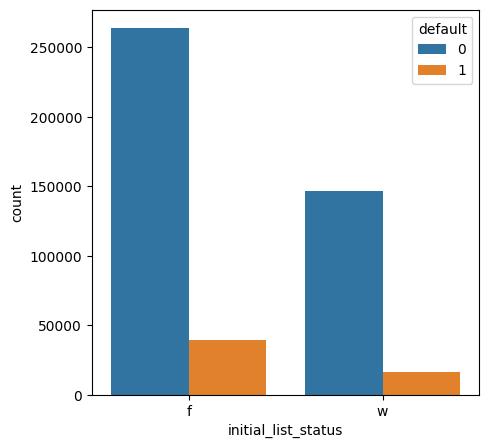

In [ ]:
plt.figure(figsize=(5,5))
sns.countplot(x=df['initial_list_status'],hue=df['default'])

In [ ]:
#df.to_csv("loannnnnnn.csv")

### 1. inq_last_6mths

In [ ]:
df['inq_last_6mths'].value_counts()

,count
inq_last_6mths,
0.0,241498
1.0,130148
2.0,57825
3.0,25126
4.0,7241
5.0,2768
6.0,1188
7.0,195
8.0,122


In [ ]:
df['inq_last_6mths']=df['inq_last_6mths'].fillna(0)

In [ ]:
df['inq_last_6mths'].isna().sum()

np.int64(0)

### 2. revol_util

<Axes: ylabel='Density'>

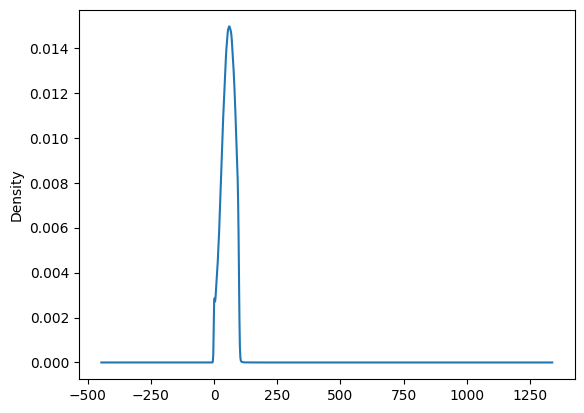

In [ ]:
df['revol_util'].plot(kind='kde')

In [ ]:
df['revol_util'].describe()

,revol_util
count,465945.000000
mean,56.176947
std,23.732628
min,0.000000
25%,39.200000
50%,57.600000
75%,74.700000
max,892.300000


In [ ]:
df['revol_util'] = np.where(df['revol_util'] > 100, 100, df['revol_util'])

<Axes: ylabel='Density'>

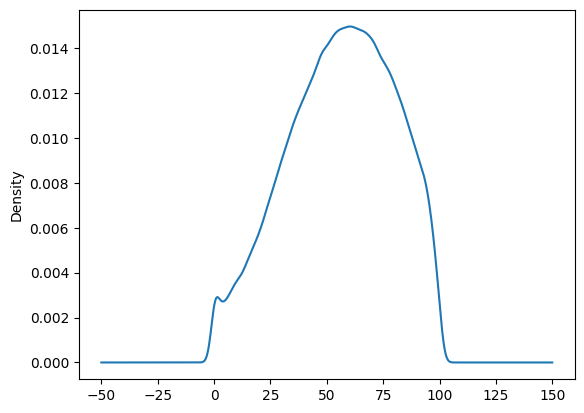

In [ ]:
df['revol_util'].plot(kind='kde')

* Missing values = 366 out of 466,271 → ~0.07%.

* Since the proportion is tiny, imputation will not distort the distribution, especially with a central value like the median.

* as the proportion of missing values are extremely low so we are using median imputer.

In [ ]:
df['revol_util'].fillna(df['revol_util'].median(),inplace=True)

In [ ]:
df['revol_util'].isna().sum()

np.int64(0)

### 3.total_rev_hi_lim

In [ ]:
df[(df['total_rev_hi_lim'].isna()) & (~(df['tot_cur_bal'].isna()))]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age


In [ ]:
df[(~(df['total_rev_hi_lim'].isna())) & ((df['tot_cur_bal'].isna()))]

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age


In [ ]:
# Step 1: Flag missingness
# if nan then 1 or else 0
df['rev_data_missing'] = df['total_rev_hi_lim'].isnull().astype(int)

In [ ]:
df.sample(10)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing
105038,11200,11200,36,10.64,364.77,B,franklin templeton investments,1,MORTGAGE,45000.0,Not Verified,2013-08-01,Fully Paid,major_purchase,FL,23.22,0.0,2003-12-01,0.0,22.0,0.0,3832,46.2,51.0,w,0.00,11672.79000,11200.00,472.79,0.0,0.00,0.0000,2014-01-01,10213.71,2014-01-01,0.0,0.0,0.0,205100.0,8300.0,0,0.248889,22.0,0
349981,12800,12800,36,20.99,482.18,E,machine operator,10,RENT,47000.0,Source Verified,2014-07-01,Charged Off,debt_consolidation,FL,32.23,0.0,2000-05-01,2.0,9.0,1.0,13335,64.4,12.0,f,0.00,3505.74000,258.29,223.89,0.0,3023.56,544.2408,2014-08-01,482.18,2014-11-01,0.0,0.0,0.0,33132.0,20700.0,1,0.272340,25.0,0
110016,22100,22100,60,17.56,555.92,D,department of homeland security,9,MORTGAGE,130000.0,Verified,2013-08-01,Fully Paid,small_business,VA,7.68,0.0,2003-04-01,0.0,10.0,0.0,4940,49.9,28.0,f,0.00,27157.16926,22100.00,5057.17,0.0,0.00,0.0000,2015-04-01,8700.75,2015-04-01,0.0,0.0,0.0,281136.0,9900.0,0,0.170000,22.0,0
423131,9000,9000,36,13.65,306.08,C,unknown,0,RENT,55000.0,Source Verified,2014-03-01,Fully Paid,credit_card,WA,5.35,0.0,1993-11-01,0.0,5.0,0.0,8047,82.1,12.0,f,0.00,9764.15000,9000.00,764.15,0.0,0.00,0.0000,2015-03-01,1788.78,2016-01-01,0.0,0.0,0.0,8047.0,9800.0,0,0.163636,32.0,0
53339,20425,20425,36,9.67,655.90,B,teacher,3,RENT,46725.0,Verified,2013-12-01,Current,credit_card,CA,10.81,0.0,1995-03-01,0.0,8.0,0.0,17370,51.4,28.0,f,6878.92,16384.40000,13546.08,2838.32,0.0,0.00,0.0000,2016-01-01,655.90,2016-01-01,0.0,0.0,0.0,17370.0,33800.0,0,0.437132,30.0,0
301251,8400,8400,36,13.35,284.45,C,waitress/hostess,10,RENT,28000.0,Not Verified,2014-10-01,Current,debt_consolidation,PA,33.30,0.0,1998-05-01,2.0,26.0,0.0,11424,44.1,40.0,f,5300.76,4266.75000,3099.24,1167.51,0.0,0.00,0.0000,2016-01-01,284.45,2016-01-01,0.0,0.0,191.0,90778.0,25900.0,0,0.300000,27.0,0
316149,8000,8000,36,19.52,295.36,E,teller,10,RENT,36000.0,Source Verified,2014-09-01,Current,other,HI,15.33,0.0,2001-04-01,1.0,9.0,0.0,3657,45.7,25.0,f,5008.02,4725.76000,2991.98,1733.78,0.0,0.00,0.0000,2016-01-01,295.36,2016-01-01,0.0,0.0,0.0,17851.0,8000.0,0,0.222222,24.0,0
131413,25450,25450,60,19.72,670.32,D,unknown,0,MORTGAGE,71000.0,Verified,2013-06-01,Charged Off,debt_consolidation,WI,17.46,0.0,1998-11-01,1.0,12.0,1.0,9028,87.7,45.0,f,0.00,7373.52000,2993.04,4367.22,0.0,13.26,0.0000,2014-05-01,670.32,2016-01-01,0.0,0.0,0.0,265575.0,10300.0,1,0.358451,27.0,0
337990,25000,25000,60,13.35,573.32,C,unknown,0,RENT,129732.0,Source Verified,2014-07-01,Current,medical,CT,5.16,2.0,1992-08-01,1.0,12.0,0.0,992,3.3,46.0,w,19298.32,9923.12000,5701.68,4221.44,0.0,0.00,0.0000,2016-01-01,573.32,2016-01-01,0.0,0.0,0.0,15436.0,30200.0,0,0.192705,33.0,0
246928,24925,24925,36,15.59,871.26,D,buyer,3,RENT,50000.0,Verified,2014-11-01,In Grace Period,credit_card,CA,19.99,0.0,2004-05-01,0.0,9.0,0.0,30650,80.2,31.0,f,17226.19,11304.79000,7698.81,3605.98,0.0,0.00,0.0000,2015-12-01,871.26,2016-01-01,0.0,0.0,0.0,30650.0,38200.0,1,0.498500,21.0,0


In [ ]:
df['tot_cur_bal'].isnull().sum()

np.int64(70272)

In [ ]:
import pandas as pd
import numpy as np

# Create the grouped table
woe_df = df.groupby('rev_data_missing')['default'].agg(['count', 'sum']).rename(columns={'sum': 'defaults'})
woe_df['non_defaults'] = woe_df['count'] - woe_df['defaults']

# Distribution of good and bad
woe_df['dist_good'] = woe_df['non_defaults'] / woe_df['non_defaults'].sum()
woe_df['dist_bad'] = woe_df['defaults'] / woe_df['defaults'].sum()

# WoE calculation
woe_df['woe'] = np.log(woe_df['dist_good'] / woe_df['dist_bad'])

# IV = sum of (dist_good - dist_bad) * WoE
woe_df['iv'] = (woe_df['dist_good'] - woe_df['dist_bad']) * woe_df['woe']
total_iv = woe_df['iv'].sum()

print(woe_df)
print(f"\nInformation Value (IV) for rev_data_missing: {total_iv:.4f}")

                   count  defaults  non_defaults  dist_good  dist_bad  \
rev_data_missing                                                        
0                 396009     44320        351689   0.855797  0.800983   
1                  70272     11012         59260   0.144203  0.199017   

                       woe        iv  
rev_data_missing                      
0                 0.066194  0.003628  
1                -0.322169  0.017659  

Information Value (IV) for rev_data_missing: 0.0213


In [ ]:
# Nature of Missingness: Not Missing Completely at Random (Not MCAR) 1st we wont remove the missing values

In [ ]:
# Step 0: Import required libraries
from sklearn.experimental import enable_iterative_imputer  # Enables the feature
from sklearn.impute import IterativeImputer
import pandas as pd
import numpy as np

# Step 1: Define the columns
columns_to_impute = ['total_rev_hi_lim', 'tot_cur_bal']  # Target columns with missing values

# Strong predictors to help impute missing values
predictor_columns = [
    'annual_inc', 'dti', 'loan_to_income', 'revol_util',
    'inq_last_6mths', 'out_prncp', 'int_rate'
]

# Final feature set for imputation
imputation_features = columns_to_impute + predictor_columns

# Step 2: Extract the relevant data subset
df_subset = df[imputation_features].copy()

# Step 3: Instantiate and fit the Iterative Imputer
imputer = IterativeImputer(max_iter=10, random_state=42)
df_imputed_array = imputer.fit_transform(df_subset)

# Step 4: Convert the result back to DataFrame
df_imputed = pd.DataFrame(df_imputed_array, columns=imputation_features)

# Step 5: Replace the original columns in your main dataset
df['total_rev_hi_lim'] = df_imputed['total_rev_hi_lim']
df['tot_cur_bal'] = df_imputed['tot_cur_bal']

## WOE-IV FOR NUMERICAL COLUMNS

In [ ]:
num_col

['loan_amnt',
 'funded_amnt',
 'term',
 'int_rate',
 'installment',
 'emp_length',
 'annual_inc',
 'dti',
 'delinq_2yrs',
 'inq_last_6mths',
 'open_acc',
 'pub_rec',
 'revol_bal',
 'revol_util',
 'total_acc',
 'out_prncp',
 'total_pymnt',
 'total_rec_prncp',
 'total_rec_int',
 'total_rec_late_fee',
 'recoveries',
 'collection_recovery_fee',
 'last_pymnt_amnt',
 'collections_12_mths_ex_med',
 'acc_now_delinq',
 'tot_coll_amt',
 'tot_cur_bal',
 'total_rev_hi_lim',
 'default',
 'loan_to_income',
 'credit_age']

In [ ]:
df2=df.copy()
df3=df.copy()

In [ ]:
def woe_iv(df,f_bins,target): # this will take 3 inputs - dataframe , column with binned classes , target column

  grouped=df.groupby(f_bins,observed=False) # grouping my data into bins provided and to ignore the error
  eps=0.00000001
  total_good=(df[target]==0).sum() # calculating the total good loans
  total_bad=(df[target]==1).sum() #calculating the total bad loans

  newdf=pd.DataFrame()

  for name, group in grouped:  #loop runs - bin size
    good=(group[target]==0).sum() #calculating the good for the particular bin
    bad=(group[target]==1).sum() #calculating the bad for the particular bin

    dist_good=good/total_good if total_good!=0 else eps
    dist_bad=bad/total_bad if total_bad!=0 else eps

    woe=np.log((dist_good+eps)/(dist_bad+eps))
    iv=(dist_good-dist_bad)*woe

    newdf=pd.concat([
        newdf,pd.DataFrame([{
            'bin':name,
            'good':good,
            'good %':dist_good,
            'bad':bad,
            'bad %':dist_bad,
            'WoE':woe,
            'IV':iv
        }])
    ],ignore_index=True)
  total_iv=newdf['IV'].sum()
  return total_iv,newdf

In [ ]:
def iv_num_col(df2, target, bins=10):
    iv_summary = []
    numerical_cols = df2.select_dtypes(include=['int64','float64']).columns.drop(target)

    for col in numerical_cols:

            # bin the column
            df2[f'{col}_bin'] = pd.qcut(df2[col], q=bins, duplicates='drop')
            #df2[f'{col}_bin'] = pd.cut(df2[col], bins=bins, duplicates='drop')
            # calculate IV
            iv,_ = woe_iv(df2, f'{col}_bin', target)
            iv_summary.append({'Feature': col, 'IV': round(iv,4)})

    iv_df = pd.DataFrame(iv_summary).sort_values(by='IV', ascending=False).reset_index(drop=True)
    return iv_df

In [ ]:
iv_result_num=pd.DataFrame(iv_num_col(df2,'default', bins=10))
iv_result_num

,Feature,IV
0,last_pymnt_amnt,1.4639
1,total_rec_prncp,1.2284
2,total_pymnt,0.5375
3,out_prncp,0.4760
4,int_rate,0.3257
5,loan_to_income,0.0634
6,annual_inc,0.0465
7,total_rev_hi_lim,0.0412
8,tot_cur_bal,0.0370
9,inq_last_6mths,0.0330


## WOE-IV FOR CATEGORICAL COLUMNS

In [ ]:
cat_col

['grade',
 'emp_title',
 'home_ownership',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'initial_list_status']

In [ ]:
#not taking into consideration as it is a column of high cardinality
df['emp_title'].nunique()

183323

In [ ]:
cat_col.pop(1)
cat_col

['grade',
 'home_ownership',
 'verification_status',
 'loan_status',
 'purpose',
 'addr_state',
 'initial_list_status']

In [ ]:
def iv_cat_col(df, target):
    iv_summary = []

    for col in cat_col:

        iv, _ = woe_iv(df3, col, target)
        iv_summary.append({'Feature': col, 'IV': iv})

    iv_df = pd.DataFrame(iv_summary).sort_values(by='IV', ascending=False).reset_index(drop=True)
    return iv_df

In [ ]:
iv_result_cat = pd.DataFrame(iv_cat_col(df3, target='default'))
iv_result_cat

,Feature,IV
0,loan_status,35.293953
1,grade,0.297149
2,purpose,0.034207
3,verification_status,0.020962
4,home_ownership,0.020138
5,initial_list_status,0.017394
6,addr_state,0.012190


In [ ]:
iv_result=pd.concat([iv_result_num,iv_result_cat], ignore_index=True).sort_values('IV',ascending=False)
iv_result

,Feature,IV
31,loan_status,35.293953
0,last_pymnt_amnt,1.463900
1,total_rec_prncp,1.228400
2,total_pymnt,0.537500
3,out_prncp,0.476000
4,int_rate,0.325700
32,grade,0.297149
5,loan_to_income,0.063400
6,annual_inc,0.046500
7,total_rev_hi_lim,0.041200


In [ ]:
#extract all importance columns according to the woe_iv information ---- 0.02 < column < 0.5
impt_col=iv_result[(iv_result['IV']<0.5) & (iv_result['IV']>0.02)]['Feature'].tolist()
impt_col

['out_prncp',
 'int_rate',
 'grade',
 'loan_to_income',
 'annual_inc',
 'total_rev_hi_lim',
 'tot_cur_bal',
 'purpose',
 'inq_last_6mths',
 'revol_util',
 'dti',
 'verification_status',
 'home_ownership']

In [ ]:
df['purpose'].nunique()

14

# GRAPHICAL REPRESENTATION BETWEEN WOE AND THE IMPORTANT VARIABLES

## 1. grade vs WoE

In [ ]:
# [1] is used because the function woe_iv returns tuple with iv and df. we only require the df
data=woe_iv(df,df['grade'],'default')[1]
data

,bin,good,good %,bad,bad %,WoE,IV
0,A,71732,0.174552,3131,0.056586,1.126467,0.132885
1,B,125240,0.304758,11689,0.211252,0.366466,0.034267
2,C,109650,0.266821,15643,0.282712,-0.057848,0.000919
3,D,64043,0.155842,12845,0.232144,-0.398518,0.030408
4,E,28176,0.068563,7581,0.137009,-0.692292,0.047385
5,F,9778,0.023794,3451,0.062369,-0.963647,0.037173
6,G,2330,0.005670,992,0.017928,-1.151216,0.014112


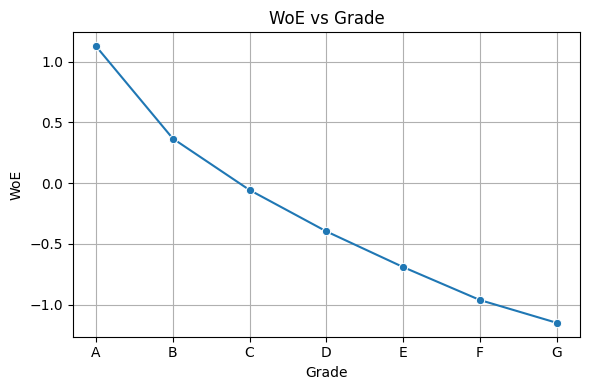

In [ ]:
plt.figure(figsize=(6, 4))
sns.lineplot(data, x='bin', y='WoE', marker='o')
plt.xlabel('Grade')
plt.ylabel('WoE')
plt.title('WoE vs Grade')
plt.grid(True)
plt.tight_layout()
plt.show()

## 2. purpose vs WoE

In [ ]:
data=woe_iv(df,'purpose','default')[1]
data

,bin,good,good %,bad,bad %,WoE,IV
0,car,4893,0.011907,504,0.009109,0.267867,0.000749
1,credit_card,94332,0.229547,9825,0.177565,0.256773,0.013348
2,debt_consolidation,240383,0.584946,33812,0.611075,-0.043700,0.001142
3,educational,334,0.000813,88,0.001590,-0.671308,0.000522
4,home_improvement,23672,0.057603,2865,0.051778,0.106607,0.000621
5,house,1929,0.004694,340,0.006145,-0.269306,0.000391
6,major_purchase,8802,0.021419,1026,0.018543,0.144193,0.000415
7,medical,3946,0.009602,656,0.011856,-0.210821,0.000475
8,moving,2514,0.006118,480,0.008675,-0.349273,0.000893
9,other,20205,0.049167,3481,0.062911,-0.246507,0.003388


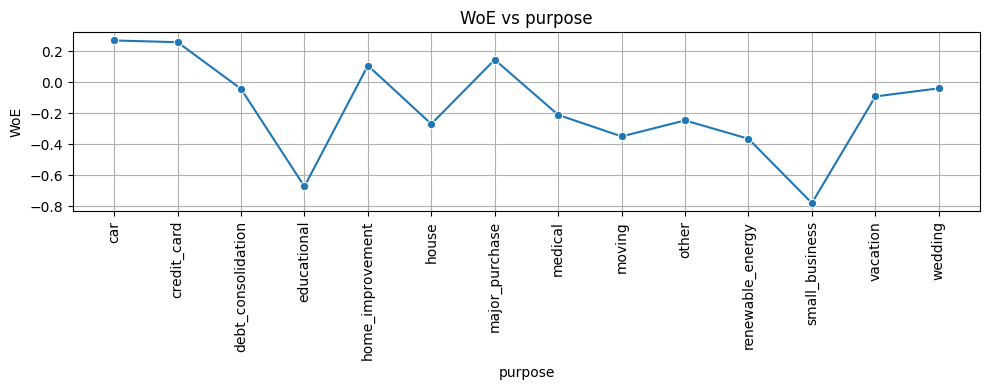

In [ ]:
plt.figure(figsize=(10,4))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xticks(rotation=90)
plt.xlabel('purpose')
plt.ylabel('WoE')
plt.title('WoE vs purpose')
plt.grid(True)
plt.tight_layout()
plt.show()

## 3. home_ownership vs WoE

In [ ]:
data=woe_iv(df,'home_ownership','default')[1]
data

,bin,good,good %,bad,bad %,WoE,IV
0,ANY,1,0.000002,0,0.000000,5.498557,1.338015e-05
1,MORTGAGE,211167,0.513852,24708,0.446541,0.140404,9.450795e-03
2,NONE,38,0.000092,8,0.000145,-0.446934,2.329103e-05
3,OTHER,144,0.000350,38,0.000687,-0.672877,2.263255e-04
4,OWN,36752,0.089432,4952,0.089496,-0.000717,4.594191e-08
5,RENT,162847,0.396271,25626,0.463132,-0.155914,1.042458e-02


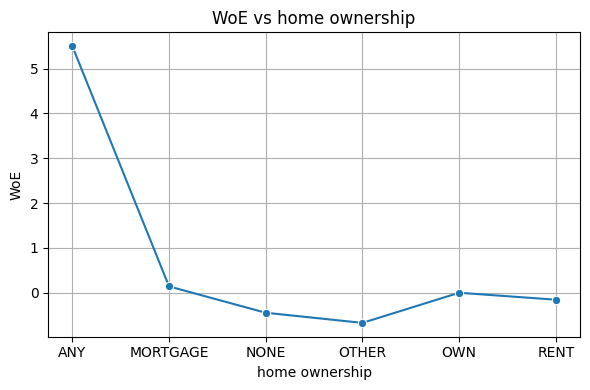

In [ ]:
plt.figure(figsize=(6,4))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('home ownership')
plt.ylabel('WoE')
plt.title('WoE vs home ownership')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#clubing categories ANY,NONE into OTHERS
df['home_ownership'] = df['home_ownership'].replace({'ANY': 'OTHER', 'NONE': 'OTHER'})

In [ ]:
df['home_ownership'].value_counts()

,count
home_ownership,
MORTGAGE,235875
RENT,188473
OWN,41704
OTHER,229


In [ ]:
data=woe_iv(df,'home_ownership','default')[1]
data

,bin,good,good %,bad,bad %,WoE,IV
0,MORTGAGE,211167,0.513852,24708,0.446541,0.140404,9.450795e-03
1,OTHER,183,0.000445,46,0.000831,-0.624263,2.409869e-04
2,OWN,36752,0.089432,4952,0.089496,-0.000717,4.594191e-08
3,RENT,162847,0.396271,25626,0.463132,-0.155914,1.042458e-02


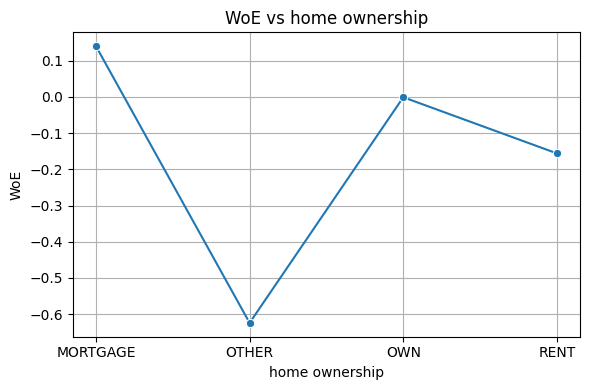

In [ ]:
plt.figure(figsize=(6,4))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('home ownership')
plt.ylabel('WoE')
plt.title('WoE vs home ownership')
plt.grid(True)
plt.tight_layout()
plt.show()

## 4. int_rate VS WoE

In [ ]:
data=woe_iv(df,pd.qcut(df['int_rate'],q=10,duplicates='drop'),'default')[1]
data['bin']=data['bin'].astype(str)  #for plotting you have to convert the bin into string datatype

data

,bin,good,good %,bad,bad %,WoE,IV
0,"(5.419, 7.9]",51494,0.125305,1976,0.035712,1.255273,0.112464
1,"(7.9, 9.91]",37747,0.091853,2196,0.039688,0.839151,0.043775
2,"(9.91, 11.49]",43146,0.104991,3643,0.065839,0.466664,0.018271
3,"(11.49, 12.49]",42979,0.104585,4094,0.073990,0.346071,0.010588
4,"(12.49, 13.66]",42332,0.103010,4895,0.088466,0.152211,0.002214
5,"(13.66, 14.49]",40171,0.097752,5499,0.099382,-0.016539,0.000027
6,"(14.49, 15.8]",42817,0.104191,6590,0.119099,-0.133736,0.001994
7,"(15.8, 17.57]",42385,0.103139,7976,0.144148,-0.334760,0.013728
8,"(17.57, 19.52]",33295,0.081020,7864,0.142124,-0.562006,0.034341
9,"(19.52, 26.06]",34583,0.084154,10599,0.191553,-0.822515,0.088337


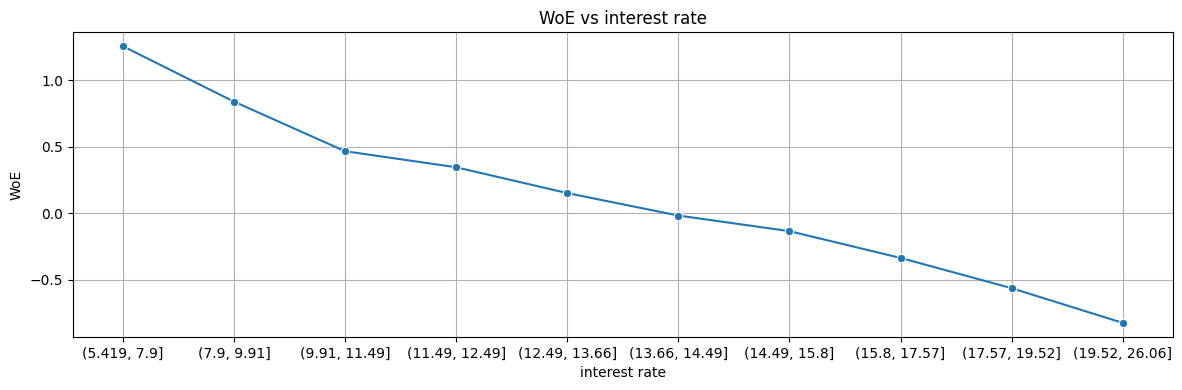

In [ ]:
plt.figure(figsize=(12,4))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('interest rate')
plt.ylabel('WoE')
plt.title('WoE vs interest rate')
plt.grid(True)
plt.tight_layout()
plt.show()

## 5.out_prncp VS WoE

In [ ]:
#if your data has repeated or constant values, it can’t make equally sized bins with distinct edges — so it drops duplicates.
data=woe_iv(df,pd.qcut(df['out_prncp'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-0.001, 441.77]",189767,0.461777,43375,0.783904,-0.529204,0.170471
1,"(441.77, 3022.96]",44822,0.109069,1807,0.032657,1.205913,0.092146
2,"(3022.96, 5598.46]",44465,0.108201,2161,0.039055,1.019013,0.070460
3,"(5598.46, 9198.47]",44215,0.107592,2413,0.043609,0.903075,0.057781
4,"(9198.47, 14041.86]",44017,0.107111,2611,0.047188,0.819725,0.049120
5,"(14041.86, 32160.38]",43663,0.106249,2965,0.053586,0.684506,0.036049


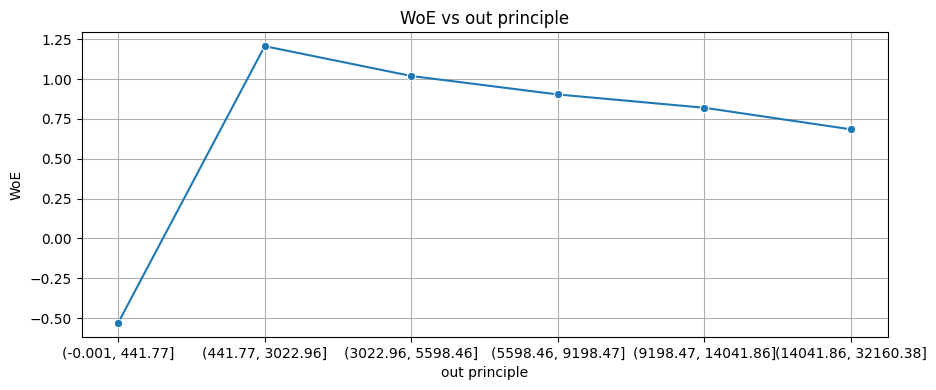

In [ ]:
plt.figure(figsize=(9.5,4))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('out principle')
plt.ylabel('WoE')
plt.title('WoE vs out principle')
plt.grid(True)
plt.tight_layout()
plt.show()

## 6. loan to income vs WoE

In [ ]:
data=woe_iv(df,pd.qcut(df['loan_to_income'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-0.00021100000000000003, 0.08]",43231,0.105198,4107,0.074225,0.348747,0.010802
1,"(0.08, 0.116]",41703,0.101480,4219,0.076249,0.285857,0.007212
2,"(0.116, 0.146]",42408,0.103195,4468,0.080749,0.245278,0.005506
3,"(0.146, 0.176]",41650,0.101351,4750,0.085845,0.166039,0.002574
4,"(0.176, 0.206]",41728,0.101541,5049,0.091249,0.106864,0.001100
5,"(0.206, 0.24]",43968,0.106991,5481,0.099057,0.077057,0.000611
6,"(0.24, 0.277]",38465,0.093600,5601,0.101225,-0.078314,0.000597
7,"(0.277, 0.321]",39809,0.096871,6570,0.118738,-0.203539,0.004451
8,"(0.321, 0.378]",39240,0.095486,7235,0.130756,-0.314351,0.011087
9,"(0.378, 1.338]",38747,0.094287,7852,0.141907,-0.408833,0.019469


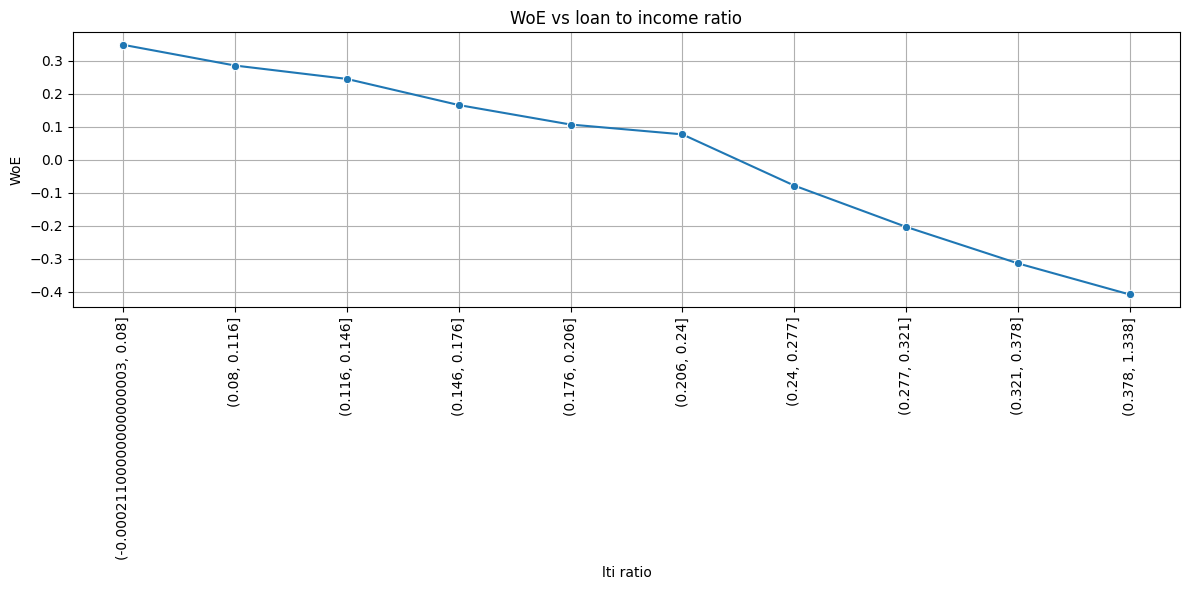

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('lti ratio')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs loan to income ratio')
plt.grid(True)
plt.tight_layout()
plt.show()

## 7. annual_inc vs WoE

In [ ]:
data=woe_iv(df,pd.qcut(df['annual_inc'],q=10,duplicates='drop'),'default')[1]
data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(1895.999, 34000.0]",41051,0.099893,7507,0.135672,-0.306138,0.010953
1,"(34000.0, 41600.0]",38382,0.093398,6544,0.118268,-0.236078,0.005871
2,"(41600.0, 49000.0]",40540,0.098650,6400,0.115665,-0.159127,0.002708
3,"(49000.0, 55000.0]",43088,0.104850,6245,0.112864,-0.073654,0.000590
4,"(55000.0, 63000.0]",40080,0.097530,5755,0.104009,-0.064309,0.000417
5,"(63000.0, 71000.0]",39641,0.096462,5172,0.093472,0.031487,0.000094
6,"(71000.0, 81000.0]",41548,0.101103,5012,0.090580,0.109897,0.001156
7,"(81000.0, 96000.0]",43149,0.104998,4710,0.085123,0.209854,0.004171
8,"(96000.0, 120000.0]",42534,0.103502,4278,0.077315,0.291700,0.007639
9,"(120000.0, 7500000.0]",40936,0.099613,3709,0.067032,0.396130,0.012907


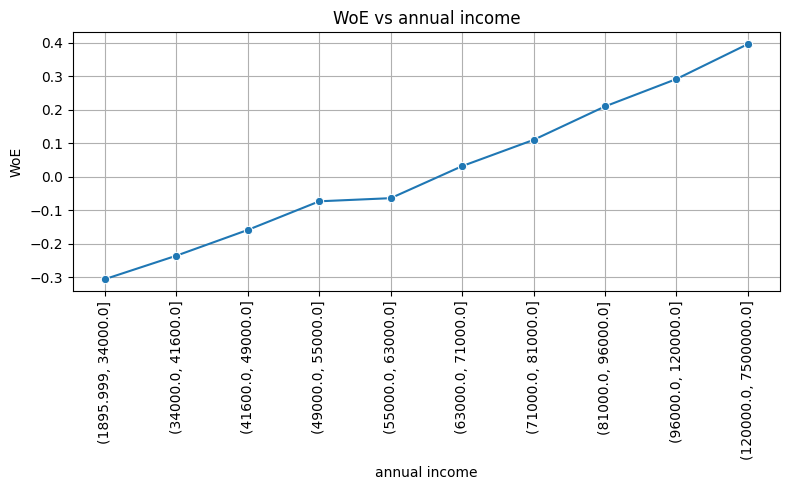

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('annual income')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs annual income')
plt.grid(True)
plt.tight_layout()
plt.show()

## 8. inq_last_6mths vs WoE

In [ ]:
data=woe_iv(df,pd.qcut(df['inq_last_6mths'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-0.001, 1.0]",331160,0.805842,40511,0.732144,0.095910,0.007068
1,"(1.0, 2.0]",49366,0.120127,8459,0.152877,-0.241087,0.007896
2,"(2.0, 33.0]",30423,0.074031,6362,0.114979,-0.440262,0.018028


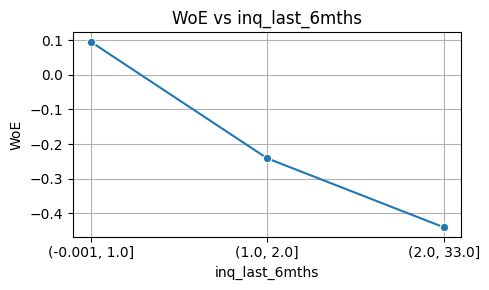

In [ ]:
plt.figure(figsize=(5,3))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('inq_last_6mths')
plt.ylabel('WoE')
plt.title('WoE vs inq_last_6mths')
plt.grid(True)
plt.tight_layout()
plt.show()

## 9. dti vs WoE

In [ ]:
data=woe_iv(df,pd.qcut(df['dti'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-0.001, 7.03]",42213,0.102721,4454,0.080496,0.243808,0.005419
1,"(7.03, 10.11]",42150,0.102567,4571,0.082610,0.216385,0.004318
2,"(10.11, 12.53]",41810,0.101740,4779,0.086370,0.163786,0.002517
3,"(12.53, 14.71]",41637,0.101319,5004,0.090436,0.113634,0.001237
4,"(14.71, 16.87]",41395,0.100730,5235,0.094611,0.062676,0.000384
5,"(16.87, 19.08]",41024,0.099827,5638,0.101894,-0.020490,0.000042
6,"(19.08, 21.46]",40707,0.099056,5969,0.107876,-0.085297,0.000752
7,"(21.46, 24.21]",40165,0.097737,6301,0.113876,-0.152830,0.002467
8,"(24.21, 28.0]",40083,0.097538,6566,0.118666,-0.196070,0.004143
9,"(28.0, 39.99]",39765,0.096764,6815,0.123166,-0.241257,0.006370


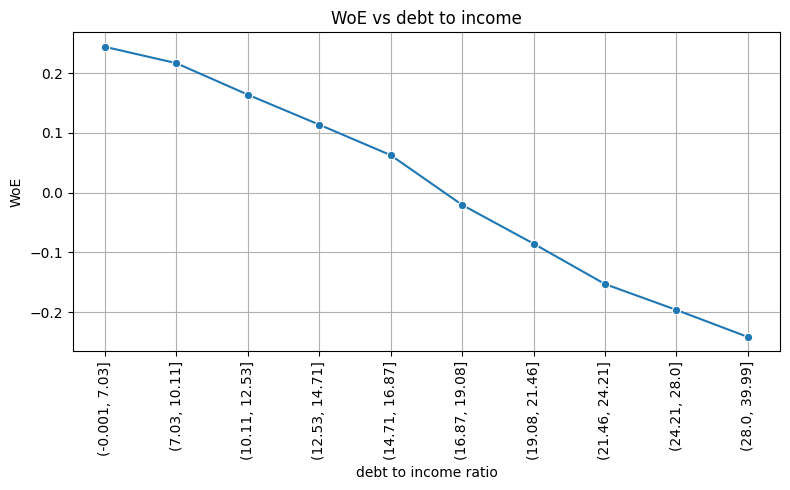

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('debt to income ratio')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs debt to income')
plt.grid(True)
plt.tight_layout()
plt.show()

## 10.tot_cur_bal vs WoE
tot_cur_bal-The sum of the current outstanding balances on all open credit lines

In [ ]:
data=woe_iv(df,pd.qcut(df['tot_cur_bal'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-61245.702999999994, 15435.0]",40905,0.099538,5724,0.103448,-0.038533,0.000151
1,"(15435.0, 26858.0]",40566,0.098713,6062,0.109557,-0.104227,0.001130
2,"(26858.0, 40696.0]",40656,0.098932,5972,0.107930,-0.087053,0.000783
3,"(40696.0, 63103.445]",40172,0.097754,6456,0.116678,-0.176957,0.003349
4,"(63103.445, 94554.0]",40035,0.097421,6593,0.119153,-0.201372,0.004376
5,"(94554.0, 129069.0]",40498,0.098548,6132,0.110822,-0.117386,0.001441
6,"(129069.0, 169125.169]",41186,0.100222,5440,0.098316,0.019202,0.000037
7,"(169125.169, 222767.98]",41648,0.101346,4980,0.090002,0.118706,0.001347
8,"(222767.98, 313169.0]",42331,0.103008,4297,0.077658,0.282485,0.007161
9,"(313169.0, 8000078.0]",42952,0.104519,3676,0.066435,0.453140,0.017257


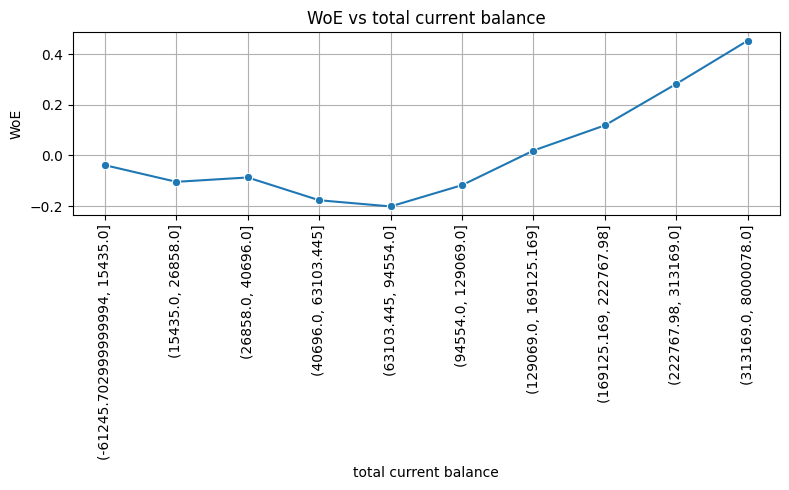

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('total current balance')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs total current balance')
plt.grid(True)
plt.tight_layout()
plt.show()

## 11.total_rev_hi_lim vs WoE
The total revolving credit limit across all revolving accounts (e.g., credit cards) for the borrower.

In [ ]:
data=woe_iv(df,pd.qcut(df['total_rev_hi_lim'],q=10,duplicates='drop'),'default')[1]
data['bin']=data['bin'].astype(str)

data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-15084.233, 8600.0]",40693,0.099022,6681,0.120744,-0.198329,0.004308
1,"(8600.0, 12500.0]",40720,0.099088,6226,0.112521,-0.127132,0.001708
2,"(12500.0, 16000.0]",39646,0.096474,6149,0.111129,-0.141417,0.002072
3,"(16000.0, 19700.0]",40818,0.099326,6205,0.112141,-0.121350,0.001555
4,"(19700.0, 23600.0]",40266,0.097983,5945,0.107442,-0.092161,0.000872
5,"(23600.0, 28000.0]",40505,0.098565,5954,0.107605,-0.087756,0.000793
6,"(28000.0, 33466.35]",41182,0.100212,5407,0.097719,0.025189,0.000063
7,"(33466.35, 40900.0]",41758,0.101614,4954,0.089532,0.126578,0.001529
8,"(40900.0, 55200.0]",42286,0.102898,4349,0.078598,0.269392,0.006546
9,"(55200.0, 9999999.0]",43075,0.104818,3462,0.062568,0.515979,0.021800


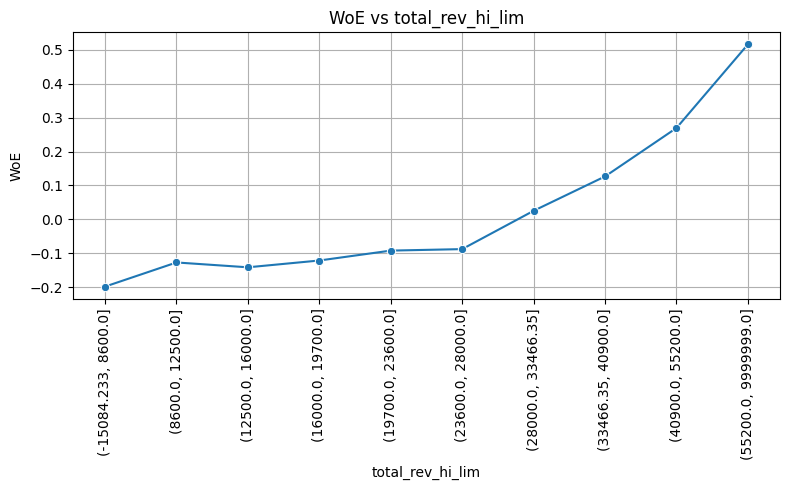

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('total_rev_hi_lim')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs total_rev_hi_lim')
plt.grid(True)
plt.tight_layout()
plt.show()

## 12. revol_util vs WoE
 the ratio of current revolving balance to total revolving credit limit (i.e., how much of their available credit is used)

 It tells you what percentage of the borrower's total revolving credit limit is currently being used.

In [ ]:
data=woe_iv(df,pd.qcut(df['revol_util'],q=10,duplicates='drop'),'default')[1]

data['bin']=data['bin'].astype(str)
data

,bin,good,good %,bad,bad %,WoE,IV
0,"(-0.001, 23.2]",42558,0.103560,4122,0.074496,0.329412,0.009574
1,"(23.2, 34.8]",42348,0.103049,4628,0.083641,0.208679,0.004050
2,"(34.8, 43.4]",41715,0.101509,4858,0.087797,0.145116,0.001990
3,"(43.4, 50.8]",41485,0.100949,5197,0.093924,0.072133,0.000507
4,"(50.8, 57.6]",41531,0.101061,5406,0.097701,0.033813,0.000114
5,"(57.6, 64.3]",40894,0.099511,5699,0.102996,-0.034425,0.000120
6,"(64.3, 71.1]",40531,0.098628,5914,0.106882,-0.080373,0.000663
7,"(71.1, 78.5]",40303,0.098073,6092,0.110099,-0.115668,0.001391
8,"(78.5, 87.1]",40080,0.097530,6386,0.115412,-0.168348,0.003010
9,"(87.1, 100.0]",39504,0.096129,7030,0.127051,-0.278902,0.008624


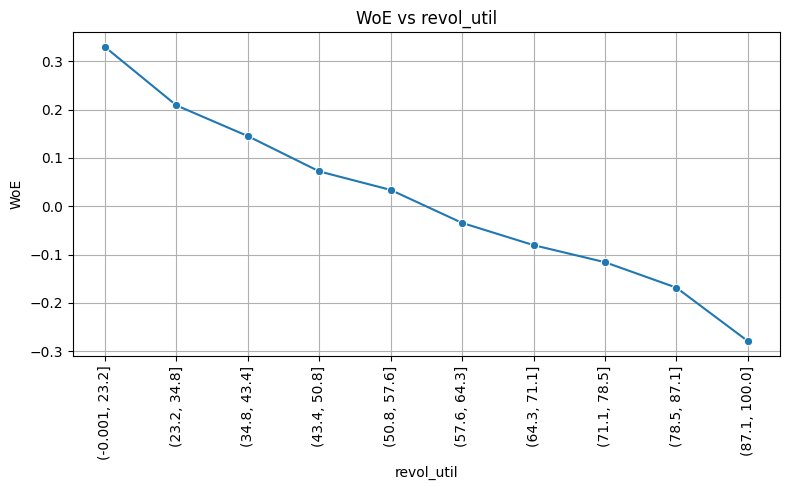

In [ ]:
plt.figure(figsize=(8,5))
sns.lineplot(data,x='bin',y='WoE',marker="o")
plt.xlabel('revol_util')
plt.ylabel('WoE')
plt.xticks(rotation=90)
plt.title('WoE vs revol_util')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df.shape

(466281, 44)

In [ ]:
df.head()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing
0,5000,5000,36,10.65,162.87,B,unknown,10,RENT,24000.0,Verified,2011-12-01,Fully Paid,credit_card,AZ,27.65,0.0,1985-01-01,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,5861.071414,5000.00,861.07,0.00,0.00,0.00,2015-01-01,171.62,2016-01-01,0.0,0.0,NaN,107945.115046,21248.894173,0,0.208333,41.0,1
1,2500,2500,60,15.27,59.83,C,ryder,0,RENT,30000.0,Source Verified,2011-12-01,Charged Off,car,GA,1.00,0.0,1999-04-01,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,1008.710000,456.46,435.17,0.00,117.08,1.11,2013-04-01,119.66,2013-09-01,0.0,0.0,NaN,68068.095091,14386.345714,1,0.083333,26.0,1
2,2400,2400,36,15.96,84.33,C,unknown,10,RENT,12252.0,Not Verified,2011-12-01,Fully Paid,small_business,IL,8.72,0.0,2001-11-01,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,3003.653644,2400.00,603.65,0.00,0.00,0.00,2014-06-01,649.91,2016-01-01,0.0,0.0,NaN,59105.936799,-3162.359291,0,0.195886,24.0,1
3,10000,10000,36,13.49,339.31,C,air resources board,10,RENT,49200.0,Source Verified,2011-12-01,Fully Paid,other,CA,20.00,0.0,1996-02-01,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,12226.302210,10000.00,2209.33,16.97,0.00,0.00,2015-01-01,357.48,2015-01-01,0.0,0.0,NaN,87224.815867,32222.096157,0,0.203252,29.0,1
4,3000,3000,60,12.69,67.79,B,university medical group,1,RENT,80000.0,Source Verified,2011-12-01,Current,other,OR,17.94,0.0,1996-01-01,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,3242.170000,2233.10,1009.07,0.00,0.00,0.00,2016-01-01,67.79,2016-01-01,0.0,0.0,NaN,146687.028810,25227.927578,0,0.037500,30.0,1


In [ ]:
impt_col

['out_prncp',
 'int_rate',
 'grade',
 'loan_to_income',
 'annual_inc',
 'total_rev_hi_lim',
 'tot_cur_bal',
 'purpose',
 'inq_last_6mths',
 'revol_util',
 'dti',
 'verification_status',
 'home_ownership']

In [ ]:
#impt_col.append('initial_list_status')

In [ ]:
impt_col.append('initial_list_status')
impt_col.append('total_pymnt')

In [ ]:
df4=df.copy()
df4=df4.dropna()

## Logistic Regression cannot train on missing values.So imputation is required.


In [ ]:
df[impt_col].isna().sum()

,0
out_prncp,0
int_rate,0
grade,0
loan_to_income,0
annual_inc,0
total_rev_hi_lim,0
tot_cur_bal,0
purpose,0
inq_last_6mths,0
revol_util,0


/usr/local/lib/python3.11/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/tmp/ipython-input-416-2542431620.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(df['total_rev_hi_lim']))


<Axes: xlabel='total_rev_hi_lim', ylabel='Density'>

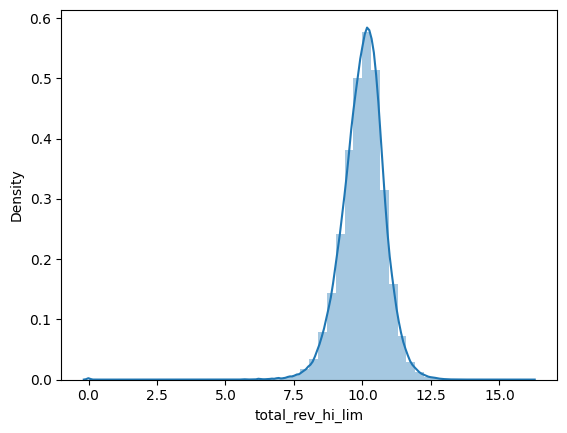

In [ ]:
sns.distplot(np.log1p(df['total_rev_hi_lim']))

/tmp/ipython-input-417-1085652713.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['loan_to_income'])


<Axes: xlabel='loan_to_income', ylabel='Density'>

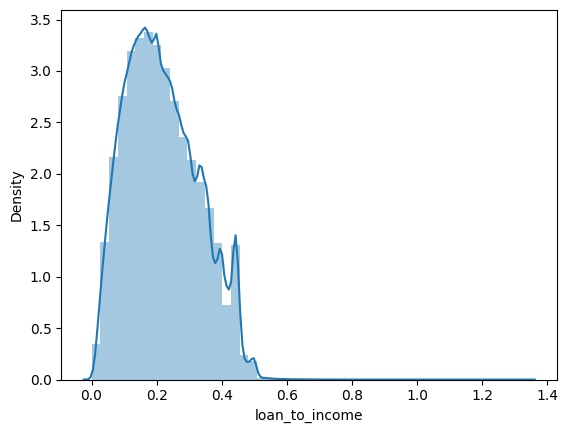

In [ ]:
sns.distplot(df['loan_to_income'])

/tmp/ipython-input-418-1146616152.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['int_rate'])


<Axes: xlabel='int_rate', ylabel='Density'>

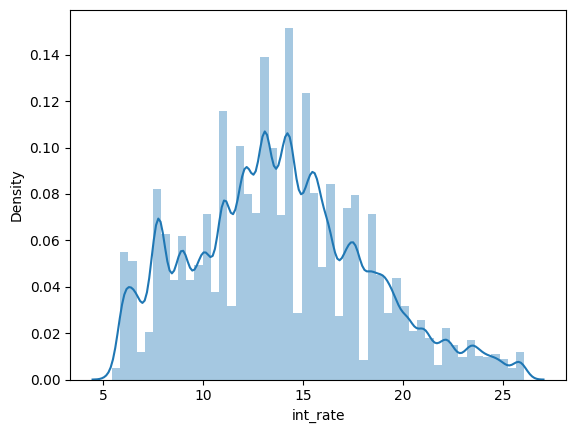

In [ ]:
sns.distplot(df['int_rate'])

/tmp/ipython-input-419-2342454688.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['revol_util'])


<Axes: xlabel='revol_util', ylabel='Density'>

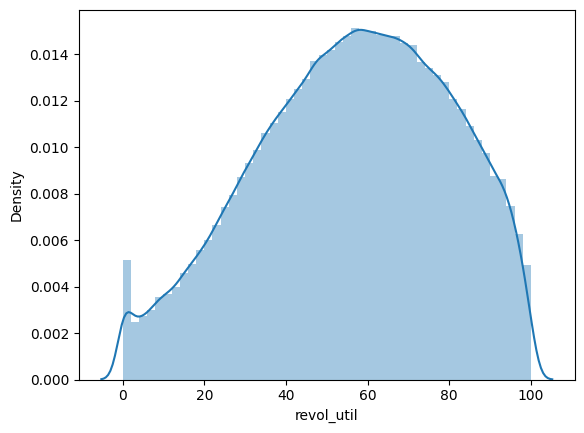

In [ ]:
sns.distplot(df['revol_util'])

In [ ]:
# imputing missing values in columns like inq_last_6mths	(25) ,total_rev_hi_lim	(70272) , revol_util	(336) ,tot_cur_bal (70272)

In [ ]:
df.sample()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing
173147,9750,9750,36,12.12,324.4,B,servpro of paducah,4,MORTGAGE,28000.0,Verified,2013-01-01,Fully Paid,debt_consolidation,KY,24.6,0.0,1991-05-01,0.0,18.0,0.0,22289,50.8,40.0,f,0.0,11489.21552,9750.0,1739.22,0.0,0.0,0.0,2015-06-01,211.35,2015-06-01,0.0,0.0,0.0,118949.0,43900.0,0,0.348214,34.0,0


In [ ]:
df['int_rate_bin']=pd.qcut(df['int_rate'],q=10,duplicates='drop')
df['out_prncp_bin']=pd.qcut(df['out_prncp'],q=10,duplicates='drop')
df['loan_to_income_bin']=pd.qcut(df['loan_to_income'],q=10,duplicates='drop')
df['annual_inc_bin']=pd.qcut(df['annual_inc'],q=10,duplicates='drop')
df['inq_last_6mths_bin']=pd.qcut(df['inq_last_6mths'],q=10,duplicates='drop')
df['dti_bin']=pd.qcut(df['dti'],q=10,duplicates='drop')
df['tot_cur_bal_bin']=pd.qcut(df['tot_cur_bal'],q=10,duplicates='drop')
df['total_rev_hi_lim_bin']=pd.qcut(df['total_rev_hi_lim'],q=10,duplicates='drop')
df['revol_util_bin']=pd.qcut(df['revol_util'],q=10,duplicates='drop')
df['term_bin']=pd.qcut(df['term'],q=10,duplicates='drop')
df['total_rec_late_fee_bin']=pd.qcut(df['total_rec_late_fee'],q=10,duplicates='drop')
df['total_rec_int_bin']=pd.qcut(df['total_rec_int'],q=10,duplicates='drop')
df['total_rec_prncp_bin']=pd.qcut(df['total_rec_prncp'],q=10,duplicates='drop')
df['total_pymnt_bin']=pd.qcut(df['total_pymnt'],q=10,duplicates='drop')

In [ ]:
df.sample(5)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing,int_rate_bin,out_prncp_bin,loan_to_income_bin,annual_inc_bin,inq_last_6mths_bin,dti_bin,tot_cur_bal_bin,total_rev_hi_lim_bin,revol_util_bin,term_bin,total_rec_late_fee_bin,total_rec_int_bin,total_rec_prncp_bin,total_pymnt_bin
301440,30000,30000,60,13.98,697.74,C,production support analyst,2,MORTGAGE,66226.0,Verified,2014-10-01,Current,debt_consolidation,IN,25.32,0.0,2000-10-01,0.0,15.0,0.0,31860,79.1,27.0,f,24328.14,10466.10,5671.86,4794.24,0.0,0.0,0.0,2016-01-01,697.74,2016-01-01,0.0,0.0,0.0,317508.0,40300.0,0,0.452994,25.0,0,"(13.66, 14.49]","(14041.86, 32160.38]","(0.378, 1.338]","(63000.0, 71000.0]","(-0.001, 1.0]","(24.21, 28.0]","(313169.0, 8000078.0]","(33466.35, 40900.0]","(78.5, 87.1]","(35.999, 60.0]","(-0.001, 358.68]","(3862.03, 5720.88]","(5414.38, 6817.76]","(9419.43, 11337.71]"
437159,5500,5500,36,13.65,187.05,C,executive assistant,1,MORTGAGE,42000.0,Source Verified,2014-02-01,Current,debt_consolidation,SC,8.29,0.0,2001-02-01,0.0,11.0,0.0,6950,39.0,30.0,f,2407.97,4115.10,3092.03,1023.07,0.0,0.0,0.0,2015-12-01,187.05,2016-01-01,0.0,0.0,575.0,144911.0,17800.0,0,0.130952,24.0,0,"(12.49, 13.66]","(441.77, 3022.96]","(0.116, 0.146]","(41600.0, 49000.0]","(-0.001, 1.0]","(7.03, 10.11]","(129069.0, 169125.169]","(16000.0, 19700.0]","(34.8, 43.4]","(35.999, 60.0]","(-0.001, 358.68]","(811.32, 1110.87]","(2146.19, 3199.04]","(3315.68, 4853.5]"
406984,15000,15000,36,14.64,517.34,C,police officer,10,OWN,70000.0,Source Verified,2014-04-01,Current,car,FL,30.19,0.0,1982-09-01,1.0,9.0,2.0,14581,84.3,22.0,w,7478.41,10346.80,7521.59,2825.21,0.0,0.0,0.0,2015-12-01,517.34,2016-01-01,0.0,0.0,0.0,205476.0,17300.0,0,0.214286,43.0,0,"(14.49, 15.8]","(5598.46, 9198.47]","(0.206, 0.24]","(63000.0, 71000.0]","(-0.001, 1.0]","(28.0, 39.99]","(169125.169, 222767.98]","(16000.0, 19700.0]","(78.5, 87.1]","(35.999, 60.0]","(-0.001, 358.68]","(2279.42, 2889.08]","(6817.76, 8483.64]","(9419.43, 11337.71]"
135003,15000,15000,60,21.98,414.12,E,ashley funiture,9,RENT,42000.0,Verified,2013-06-01,Current,debt_consolidation,WI,16.97,0.0,2004-03-01,1.0,7.0,0.0,14913,90.4,21.0,f,9252.58,12837.40,5747.42,7089.98,0.0,0.0,0.0,2016-01-01,414.12,2016-01-01,0.0,0.0,0.0,22723.0,16500.0,0,0.357143,21.0,0,"(19.52, 26.06]","(9198.47, 14041.86]","(0.321, 0.378]","(41600.0, 49000.0]","(-0.001, 1.0]","(16.87, 19.08]","(15435.0, 26858.0]","(16000.0, 19700.0]","(87.1, 100.0]","(35.999, 60.0]","(-0.001, 358.68]","(5720.88, 24205.62]","(5414.38, 6817.76]","(11337.71, 13701.03]"
234191,35000,35000,60,11.44,768.69,B,registered nurse,3,MORTGAGE,78000.0,Verified,2014-12-01,Current,debt_consolidation,CO,13.71,0.0,2003-06-01,1.0,13.0,0.0,37361,46.9,20.0,w,29009.63,9970.73,5990.37,3980.36,0.0,0.0,0.0,2016-01-01,768.69,2016-01-01,0.0,0.0,0.0,285526.0,79700.0,0,0.448718,22.0,0,"(9.91, 11.49]","(14041.86, 32160.38]","(0.378, 1.338]","(71000.0, 81000.0]","(-0.001, 1.0]","(12.53, 14.71]","(222767.98, 313169.0]","(55200.0, 9999999.0]","(43.4, 50.8]","(35.999, 60.0]","(-0.001, 358.68]","(3862.03, 5720.88]","(5414.38, 6817.76]","(9419.43, 11337.71]"


In [ ]:
#df.to_csv("loan3.csv",index=False)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
impt_col

['out_prncp',
 'int_rate',
 'grade',
 'loan_to_income',
 'annual_inc',
 'total_rev_hi_lim',
 'tot_cur_bal',
 'purpose',
 'inq_last_6mths',
 'revol_util',
 'dti',
 'verification_status',
 'home_ownership',
 'initial_list_status',
 'total_pymnt']

In [ ]:
df['default'].value_counts(normalize=True)

,proportion
default,
0,0.881333
1,0.118667


In [ ]:
# Features and target
X = df[impt_col]
y = df['default']  # target variable: 0 or 1

In [ ]:
X = pd.get_dummies(X, columns=['grade', 'purpose', 'home_ownership','verification_status','initial_list_status'], drop_first=True)

In [ ]:
X.isna().sum()

,0
out_prncp,0
int_rate,0
loan_to_income,0
annual_inc,0
total_rev_hi_lim,0
tot_cur_bal,0
inq_last_6mths,0
revol_util,0
dti,0
total_pymnt,0


In [ ]:
scaler=StandardScaler()
num_c=X.select_dtypes(include=['int64','float64']).columns
X[num_c]=scaler.fit_transform(X[num_c])

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.head()

,out_prncp,int_rate,loan_to_income,annual_inc,total_rev_hi_lim,tot_cur_bal,inq_last_6mths,revol_util,dti,total_pymnt,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified,initial_list_status_w
412301,0.794545,0.633545,1.635047,-0.550863,-0.499280,-0.790132,2.011114,0.170415,-0.450756,0.009030,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False
36159,-0.693948,-0.227028,-1.166165,0.377025,-0.070618,0.358170,0.178913,1.070353,0.677761,-0.740235,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
138787,0.968533,0.452251,1.184167,-0.387118,0.753485,-0.194291,-0.737187,-0.209841,0.654834,0.256451,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True
29626,-0.693948,-0.736486,-1.408393,0.122311,-0.223595,-0.082967,-0.737187,-0.577421,-1.577999,-0.619734,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False
140954,-0.693948,-0.165066,-0.005029,-0.605445,-0.548126,0.425253,-0.737187,0.690097,-0.221486,-0.118262,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression without regularization
model = LogisticRegression(penalty=None, max_iter=100, solver='lbfgs')
model.fit(X_train, y_train)


LogisticRegression(penalty=None)

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities of default (class 1)
y_pred_proba

array([0.74896358, 0.00676715, 0.03029289, ..., 0.0102435 , 0.13035795,
       0.55243172])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for threshold in [ 0.3,0.25,0.2]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     82257
           1       0.66      0.55      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.80      0.76      0.78     93257
weighted avg       0.91      0.91      0.91     93257

[[79154  3103]
 [ 4897  6103]]
AUC Score: 0.8555759123014676
--- Threshold: 0.25 ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     82257
           1       0.60      0.61      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.77      0.78      0.77     93257
weighted avg       0.91      0.91      0.91     93257

[[77741  4516]
 [ 4317  6683]]
AUC Score: 0.8555759123014676
--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     82257
           1       0.51      0.67      0.58  

### LOGISTIC WITH REGULARIZATION TERM

In [ ]:
model=LogisticRegression(max_iter=100)
model.fit(X_train,y_train)

LogisticRegression()

In [ ]:
y_pred=model.predict(X_test)

In [ ]:
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities of default (class 1)
y_pred_proba

array([0.74843509, 0.00670986, 0.03060246, ..., 0.01012686, 0.12970811,
       0.55282001])

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

for threshold in [ 0.3,0.25,0.2]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.94      0.96      0.95     82257
           1       0.66      0.55      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.80      0.76      0.78     93257
weighted avg       0.91      0.91      0.91     93257

[[79165  3092]
 [ 4900  6100]]
AUC Score: 0.8556293180906405
--- Threshold: 0.25 ---
              precision    recall  f1-score   support

           0       0.95      0.95      0.95     82257
           1       0.60      0.61      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.77      0.78      0.77     93257
weighted avg       0.91      0.91      0.91     93257

[[77744  4513]
 [ 4317  6683]]
AUC Score: 0.8556293180906405
--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     82257
           1       0.51      0.67      0.58  

In [ ]:
import statsmodels.api as sm
# Add constant (intercept) for statsmodels
X_with_const = sm.add_constant(X).astype(float)
y = y.astype(float)
logit_model = sm.Logit(y, X_with_const)
result = logit_model.fit(disp=False)

# Create summary table
summary_df = pd.DataFrame({
    'Feature': result.params.index,
    'Coefficient': result.params.values,
    'P-Value': result.pvalues,
    'Odds Ratio': np.exp(result.params.values)
}).sort_values(by='P-Value')

# Display result
print(summary_df)

                                                                 Feature  \
const                                                              const   
out_prncp                                                      out_prncp   
int_rate                                                        int_rate   
loan_to_income                                            loan_to_income   
annual_inc                                                    annual_inc   
total_pymnt                                                  total_pymnt   
initial_list_status_w                              initial_list_status_w   
inq_last_6mths                                            inq_last_6mths   
revol_util                                                    revol_util   
verification_status_Verified                verification_status_Verified   
home_ownership_OWN                                    home_ownership_OWN   
tot_cur_bal                                                  tot_cur_bal   
purpose_smal

In [ ]:
#Drop non-significant features
drop_cols = ['purpose_vacation', 'grade_B', 'purpose_renewable_energy']

# Drop from X
X_dropped = X.drop(columns=drop_cols)

# Split data again
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_dropped, y, test_size=0.2, random_state=42)


model = LogisticRegression(penalty=None, max_iter=100, solver='lbfgs')
model.fit(X_train, y_train)

# Predict probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]

for threshold in [ 0.3,0.25,0.2]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95     82257
         1.0       0.66      0.55      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.80      0.76      0.78     93257
weighted avg       0.91      0.91      0.91     93257

[[79159  3098]
 [ 4907  6093]]
AUC Score: 0.8556035927309863
--- Threshold: 0.25 ---
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95     82257
         1.0       0.60      0.61      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.77      0.78      0.77     93257
weighted avg       0.91      0.91      0.91     93257

[[77736  4521]
 [ 4312  6688]]
AUC Score: 0.8556035927309863
--- Threshold: 0.2 ---
              precision    recall  f1-score   support

         0.0       0.95      0.91      0.93     82257
         1.0       0.51      0.67      0.58  

In [ ]:
for threshold in [ 0.3,0.25]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

         0.0       0.94      0.96      0.95     82257
         1.0       0.66      0.55      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.80      0.76      0.78     93257
weighted avg       0.91      0.91      0.91     93257

[[79159  3098]
 [ 4907  6093]]
AUC Score: 0.8556035927309863
--- Threshold: 0.25 ---
              precision    recall  f1-score   support

         0.0       0.95      0.95      0.95     82257
         1.0       0.60      0.61      0.60     11000

    accuracy                           0.91     93257
   macro avg       0.77      0.78      0.77     93257
weighted avg       0.91      0.91      0.91     93257

[[77736  4521]
 [ 4312  6688]]
AUC Score: 0.8556035927309863


### To improved the performance we use binned transformed WoE variables


In [ ]:
df.sample(10)

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing,int_rate_bin,out_prncp_bin,loan_to_income_bin,annual_inc_bin,inq_last_6mths_bin,dti_bin,tot_cur_bal_bin,total_rev_hi_lim_bin,revol_util_bin,term_bin,total_rec_late_fee_bin,total_rec_int_bin,total_rec_prncp_bin,total_pymnt_bin
143365,7750,7750,36,18.49,282.09,D,suntrust,1,RENT,45500.0,Not Verified,2013-05-01,Fully Paid,debt_consolidation,MD,23.45,1.0,2007-08-01,0.0,10.0,0.0,2508,48.2,16.0,w,0.00,9746.71000,7750.00,1996.71,0.0,0.0,0.0,2015-03-01,3822.82,2016-01-01,0.0,0.0,0.0,33276.0,5200.0,0,0.170330,18.0,0,"(17.57, 19.52]","(-0.001, 441.77]","(0.146, 0.176]","(41600.0, 49000.0]","(-0.001, 1.0]","(21.46, 24.21]","(26858.0, 40696.0]","(-15084.233, 8600.0]","(43.4, 50.8]","(35.999, 60.0]","(-0.001, 358.68]","(1818.88, 2279.42]","(6817.76, 8483.64]","(9419.43, 11337.71]"
321525,35000,35000,60,18.99,907.73,E,dsitrict manager,10,MORTGAGE,132000.0,Verified,2014-08-01,Current,debt_consolidation,IL,15.51,7.0,1989-08-01,0.0,11.0,1.0,46966,55.1,23.0,w,28159.16,15431.41000,6840.84,8590.57,0.0,0.0,0.0,2016-01-01,907.73,2016-01-01,0.0,0.0,0.0,226608.0,85300.0,0,0.265152,36.0,0,"(17.57, 19.52]","(14041.86, 32160.38]","(0.24, 0.277]","(120000.0, 7500000.0]","(-0.001, 1.0]","(14.71, 16.87]","(222767.98, 313169.0]","(55200.0, 9999999.0]","(50.8, 57.6]","(35.999, 60.0]","(-0.001, 358.68]","(5720.88, 24205.62]","(6817.76, 8483.64]","(13701.03, 17141.48]"
410136,10975,10975,36,16.59,389.06,D,crew supervisor,9,RENT,44160.0,Source Verified,2014-04-01,Current,debt_consolidation,MA,23.41,1.0,2004-12-01,1.0,9.0,0.0,5138,71.4,13.0,f,5237.76,8170.26000,5737.24,2433.02,0.0,0.0,0.0,2016-01-01,389.06,2016-01-01,0.0,0.0,0.0,27110.0,7200.0,0,0.248528,21.0,0,"(15.8, 17.57]","(3022.96, 5598.46]","(0.24, 0.277]","(41600.0, 49000.0]","(-0.001, 1.0]","(21.46, 24.21]","(26858.0, 40696.0]","(-15084.233, 8600.0]","(71.1, 78.5]","(35.999, 60.0]","(-0.001, 358.68]","(2279.42, 2889.08]","(5414.38, 6817.76]","(7703.81, 9419.43]"
325210,7075,7075,36,22.15,270.75,E,shipping clerk,9,RENT,21000.0,Source Verified,2014-08-01,Current,debt_consolidation,FL,38.80,1.0,2008-10-01,2.0,10.0,0.0,11057,69.5,16.0,f,4305.81,4602.75000,2769.19,1833.56,0.0,0.0,0.0,2016-01-01,270.75,2016-01-01,0.0,0.0,0.0,15272.0,15900.0,0,0.336905,17.0,0,"(19.52, 26.06]","(3022.96, 5598.46]","(0.321, 0.378]","(1895.999, 34000.0]","(1.0, 2.0]","(28.0, 39.99]","(-61245.702999999994, 15435.0]","(12500.0, 16000.0]","(64.3, 71.1]","(35.999, 60.0]","(-0.001, 358.68]","(1818.88, 2279.42]","(2146.19, 3199.04]","(3315.68, 4853.5]"
186660,20000,20000,60,21.00,541.07,E,boulder county attorney,10,RENT,61248.0,Verified,2012-11-01,Current,debt_consolidation,CO,25.86,0.0,1988-08-01,0.0,7.0,0.0,21856,93.8,21.0,w,9809.54,20560.66000,10190.46,10370.20,0.0,0.0,0.0,2016-01-01,541.07,2016-01-01,0.0,0.0,0.0,25118.0,23300.0,0,0.326541,37.0,0,"(19.52, 26.06]","(9198.47, 14041.86]","(0.321, 0.378]","(55000.0, 63000.0]","(-0.001, 1.0]","(24.21, 28.0]","(15435.0, 26858.0]","(19700.0, 23600.0]","(87.1, 100.0]","(35.999, 60.0]","(-0.001, 358.68]","(5720.88, 24205.62]","(8483.64, 10389.3]","(17141.48, 22858.344]"
187327,12000,12000,36,17.77,432.45,D,us army,10,RENT,64000.0,Source Verified,2012-11-01,Fully Paid,debt_consolidation,WA,11.11,1.0,1997-03-01,0.0,8.0,0.0,23418,74.6,19.0,f,0.00,15567.98571,12000.00,3567.99,0.0,0.0,0.0,2015-11-01,432.23,2016-01-01,0.0,0.0,0.0,183583.0,31400.0,0,0.187500,28.0,0,"(17.57, 19.52]","(-0.001, 441.77]","(0.176, 0.206]","(63000.0, 71000.0]","(-0.0

In [ ]:
# List of the manually binned numerical columns
binned_numerical_features = [
    'int_rate_bin',
    'out_prncp_bin',
    'loan_to_income_bin',
    'annual_inc_bin',
    'total_pymnt_bin',
    'inq_last_6mths_bin',
    'dti_bin',
    'tot_cur_bal_bin',
    'total_rev_hi_lim_bin',
    'revol_util_bin',
    'term_bin'

]

# List of categorical columns (excluding those that were binned)
categorical_features = [
    'grade',
    'purpose',
    'initial_list_status',
    'home_ownership',
    'verification_status'
]

# Combine the binned numerical and categorical features for modeling
features_for_model = binned_numerical_features + categorical_features

# Create the feature matrix X using the selected columns
X_manual_binned = df[features_for_model]

# Apply one-hot encoding to the categorical and binned categorical features
X_manual_binned = pd.get_dummies(X_manual_binned, columns=features_for_model, drop_first=True)

# Define the target variable y
y_manual_binned = df['default']

# Split the data into training and testing sets
X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(
    X_manual_binned, y_manual_binned, test_size=0.2, random_state=42
)

# Initialize and train the Logistic Regression model
model_manual = LogisticRegression(max_iter=1000) # Increased max_iter for convergence
model_manual.fit(X_train_manual, y_train_manual)

# Predict on the test set
y_pred_manual = model_manual.predict(X_test_manual)
y_pred_proba_manual = model_manual.predict_proba(X_test_manual)[:, 1]

# Evaluate the model
print("Logistic Regression Model Evaluation (Manual Binning + One-Hot Encoding):")

# Evaluate with different thresholds
print("\nEvaluation at different thresholds:")
for threshold in [0.3,0.2,0.1]:
    y_pred_threshold = (y_pred_proba_manual > threshold).astype(int)
    print(f"--- Threshold: {threshold} ---")
    print(classification_report(y_test_manual, y_pred_threshold))
    print(confusion_matrix(y_test_manual, y_pred_threshold))
    print("AUC Score:", roc_auc_score(y_test_manual, y_pred_proba_manual))

Logistic Regression Model Evaluation (Manual Binning + One-Hot Encoding):

Evaluation at different thresholds:
--- Threshold: 0.3 ---
              precision    recall  f1-score   support

           0       0.96      0.98      0.97     82257
           1       0.82      0.66      0.73     11000

    accuracy                           0.94     93257
   macro avg       0.89      0.82      0.85     93257
weighted avg       0.94      0.94      0.94     93257

[[80604  1653]
 [ 3701  7299]]
AUC Score: 0.8734202714994137
--- Threshold: 0.2 ---
              precision    recall  f1-score   support

           0       0.96      0.95      0.96     82257
           1       0.66      0.72      0.69     11000

    accuracy                           0.92     93257
   macro avg       0.81      0.83      0.82     93257
weighted avg       0.93      0.92      0.92     93257

[[78186  4071]
 [ 3109  7891]]
AUC Score: 0.8734202714994137
--- Threshold: 0.1 ---
              precision    recall  f1-score 

In [ ]:
X_test_manual.sample()

,"int_rate_bin_(7.9, 9.91]","int_rate_bin_(9.91, 11.49]","int_rate_bin_(11.49, 12.49]","int_rate_bin_(12.49, 13.66]","int_rate_bin_(13.66, 14.49]","int_rate_bin_(14.49, 15.8]","int_rate_bin_(15.8, 17.57]","int_rate_bin_(17.57, 19.52]","int_rate_bin_(19.52, 26.06]","out_prncp_bin_(441.77, 3022.96]","out_prncp_bin_(3022.96, 5598.46]","out_prncp_bin_(5598.46, 9198.47]","out_prncp_bin_(9198.47, 14041.86]","out_prncp_bin_(14041.86, 32160.38]","loan_to_income_bin_(0.08, 0.116]","loan_to_income_bin_(0.116, 0.146]","loan_to_income_bin_(0.146, 0.176]","loan_to_income_bin_(0.176, 0.206]","loan_to_income_bin_(0.206, 0.24]","loan_to_income_bin_(0.24, 0.277]","loan_to_income_bin_(0.277, 0.321]","loan_to_income_bin_(0.321, 0.378]","loan_to_income_bin_(0.378, 1.338]","annual_inc_bin_(34000.0, 41600.0]","annual_inc_bin_(41600.0, 49000.0]","annual_inc_bin_(49000.0, 55000.0]","annual_inc_bin_(55000.0, 63000.0]","annual_inc_bin_(63000.0, 71000.0]","annual_inc_bin_(71000.0, 81000.0]","annual_inc_bin_(81000.0, 96000.0]","annual_inc_bin_(96000.0, 120000.0]","annual_inc_bin_(120000.0, 7500000.0]","total_pymnt_bin_(3315.68, 4853.5]","total_pymnt_bin_(4853.5, 6238.98]","total_pymnt_bin_(6238.98, 7703.81]","total_pymnt_bin_(7703.81, 9419.43]","total_pymnt_bin_(9419.43, 11337.71]","total_pymnt_bin_(11337.71, 13701.03]","total_pymnt_bin_(13701.03, 17141.48]","total_pymnt_bin_(17141.48, 22858.344]","total_pymnt_bin_(22858.344, 57777.58]","inq_last_6mths_bin_(1.0, 2.0]","inq_last_6mths_bin_(2.0, 33.0]","dti_bin_(7.03, 10.11]","dti_bin_(10.11, 12.53]","dti_bin_(12.53, 14.71]","dti_bin_(14.71, 16.87]","dti_bin_(16.87, 19.08]","dti_bin_(19.08, 21.46]","dti_bin_(21.46, 24.21]","dti_bin_(24.21, 28.0]","dti_bin_(28.0, 39.99]","tot_cur_bal_bin_(15435.0, 26858.0]","tot_cur_bal_bin_(26858.0, 40696.0]","tot_cur_bal_bin_(40696.0, 63103.445]","tot_cur_bal_bin_(63103.445, 94554.0]","tot_cur_bal_bin_(94554.0, 129069.0]","tot_cur_bal_bin_(129069.0, 169125.169]","tot_cur_bal_bin_(169125.169, 222767.98]","tot_cur_bal_bin_(222767.98, 313169.0]","tot_cur_bal_bin_(313169.0, 8000078.0]","total_rev_hi_lim_bin_(8600.0, 12500.0]","total_rev_hi_lim_bin_(12500.0, 16000.0]","total_rev_hi_lim_bin_(16000.0, 19700.0]","total_rev_hi_lim_bin_(19700.0, 23600.0]","total_rev_hi_lim_bin_(23600.0, 28000.0]","total_rev_hi_lim_bin_(28000.0, 33466.35]","total_rev_hi_lim_bin_(33466.35, 40900.0]","total_rev_hi_lim_bin_(40900.0, 55200.0]","total_rev_hi_lim_bin_(55200.0, 9999999.0]","revol_util_bin_(23.2, 34.8]","revol_util_bin_(34.8, 43.4]","revol_util_bin_(43.4, 50.8]","revol_util_bin_(50.8, 57.6]","revol_util_bin_(57.6, 64.3]","revol_util_bin_(64.3, 71.1]","revol_util_bin_(71.1, 78.5]","revol_util_bin_(78.5, 87.1]","revol_util_bin_(87.1, 100.0]",grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
44719,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True


In [ ]:
df.sample()

,loan_amnt,funded_amnt,term,int_rate,installment,grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,purpose,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,total_pymnt,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,last_credit_pull_d,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,default,loan_to_income,credit_age,rev_data_missing,int_rate_bin,out_prncp_bin,loan_to_income_bin,annual_inc_bin,inq_last_6mths_bin,dti_bin,tot_cur_bal_bin,total_rev_hi_lim_bin,revol_util_bin,term_bin,total_rec_late_fee_bin,total_rec_int_bin,total_rec_prncp_bin,total_pymnt_bin
168438,18000,18000,60,17.27,449.97,C,ctg,7,MORTGAGE,45000.0,Verified,2013-02-01,Current,debt_consolidation,NY,16.91,0.0,1993-08-01,0.0,8.0,0.0,15830,81.6,23.0,f,9708.99,15283.38,8291.01,6992.37,0.0,0.0,0.0,2015-12-01,449.97,2016-01-01,0.0,0.0,0.0,123695.0,19400.0,0,0.4,32.0,0,"(15.8, 17.57]","(9198.47, 14041.86]","(0.378, 1.338]","(41600.0, 49000.0]","(-0.001, 1.0]","(16.87, 19.08]","(94554.0, 129069.0]","(16000.0, 19700.0]","(78.5, 87.1]","(35.999, 60.0]","(-0.001, 358.68]","(5720.88, 24205.62]","(6817.76, 8483.64]","(13701.03, 17141.48]"



--- Threshold: 0.4 ---
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.97     82257
         1.0       0.91      0.52      0.67     11000

    accuracy                           0.94     93257
   macro avg       0.93      0.76      0.82     93257
weighted avg       0.94      0.94      0.93     93257

[[81704   553]
 [ 5235  5765]]
AUC Score: 0.8561037662448181

--- Threshold: 0.3 ---
              precision    recall  f1-score   support

         0.0       0.94      0.99      0.96     82257
         1.0       0.84      0.55      0.67     11000

    accuracy                           0.94     93257
   macro avg       0.89      0.77      0.82     93257
weighted avg       0.93      0.94      0.93     93257

[[81126  1131]
 [ 4913  6087]]
AUC Score: 0.8561037662448181

--- Threshold: 0.2 ---
              precision    recall  f1-score   support

         0.0       0.95      0.97      0.96     82257
         1.0       0.71      0.59      0.65

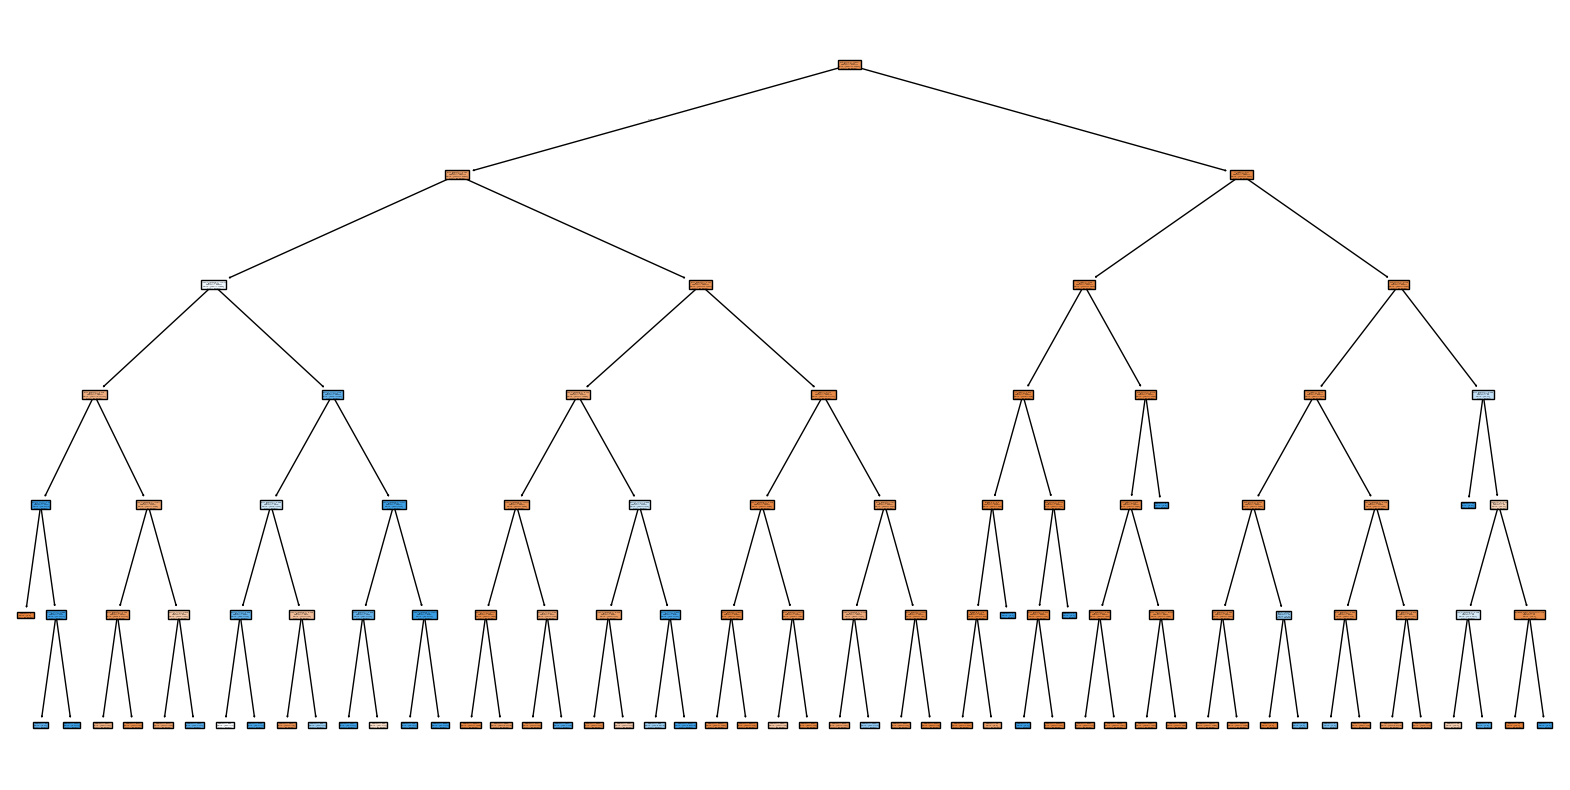

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit a Decision Tree model
model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

# 3. Get predicted probabilities for class 1 (default)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 4. Evaluate using different thresholds
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

for threshold in [0.4, 0.3, 0.2]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

# 5. Plot the decision tree
plt.figure(figsize=(20, 10))
plot_tree(model, filled=True, feature_names=X.columns, class_names=['No Default', 'Default'])
plt.show()


--- Threshold: 0.2 ---
              precision    recall  f1-score   support

         0.0       0.94      0.94      0.94     82257
         1.0       0.53      0.55      0.54     11000

    accuracy                           0.89     93257
   macro avg       0.74      0.74      0.74     93257
weighted avg       0.89      0.89      0.89     93257

[[77008  5249]
 [ 5003  5997]]
AUC Score: 0.8261534718791548

--- Threshold: 0.1 ---
              precision    recall  f1-score   support

         0.0       0.96      0.58      0.73     82257
         1.0       0.21      0.84      0.34     11000

    accuracy                           0.61     93257
   macro avg       0.59      0.71      0.53     93257
weighted avg       0.87      0.61      0.68     93257

[[47946 34311]
 [ 1813  9187]]
AUC Score: 0.8261534718791548


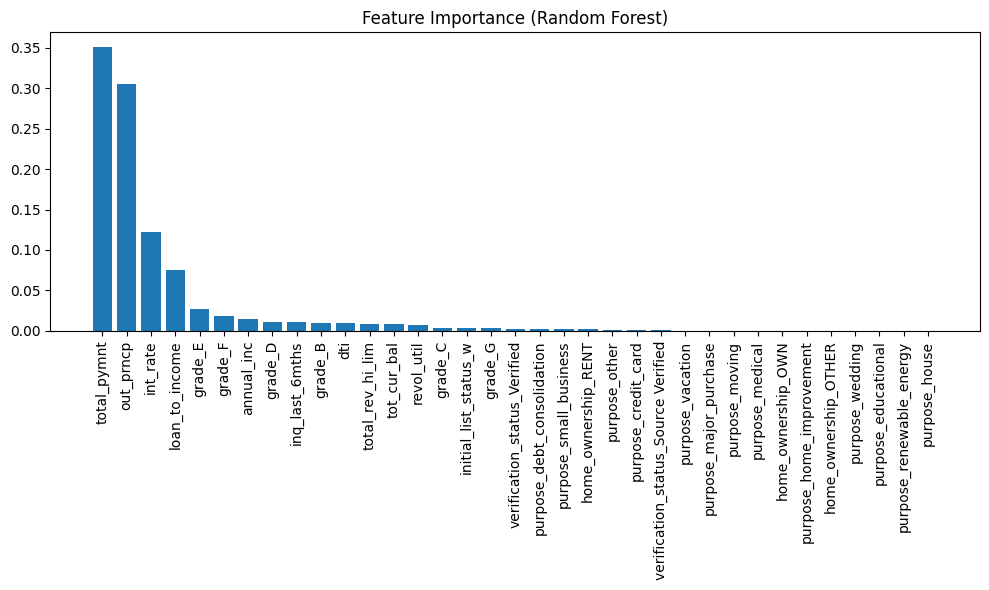

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# 3. Predict probabilities for class 1
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

# 4. Evaluate with different thresholds
for threshold in [ 0.2, 0.1]:
    y_pred = (y_pred_proba > threshold).astype(int)
    print(f"\n--- Threshold: {threshold} ---")
    print(classification_report(y_test, y_pred))
    print(confusion_matrix(y_test, y_pred))
    print("AUC Score:", roc_auc_score(y_test, y_pred_proba))

# 5. Plot Feature Importance
importances = rf_model.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Random Forest)")
plt.bar(range(X.shape[1]), importances[indices])
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
X2=df[impt_col]
y2=df['default']

In [ ]:
X2.isna().sum()

,0
out_prncp,0
int_rate,0
grade,0
loan_to_income,0
annual_inc,0
total_rev_hi_lim,0
tot_cur_bal,0
purpose,0
inq_last_6mths,0
revol_util,0


In [ ]:
X_train_manual.sample()

,"int_rate_bin_(7.9, 9.91]","int_rate_bin_(9.91, 11.49]","int_rate_bin_(11.49, 12.49]","int_rate_bin_(12.49, 13.66]","int_rate_bin_(13.66, 14.49]","int_rate_bin_(14.49, 15.8]","int_rate_bin_(15.8, 17.57]","int_rate_bin_(17.57, 19.52]","int_rate_bin_(19.52, 26.06]","out_prncp_bin_(441.77, 3022.96]","out_prncp_bin_(3022.96, 5598.46]","out_prncp_bin_(5598.46, 9198.47]","out_prncp_bin_(9198.47, 14041.86]","out_prncp_bin_(14041.86, 32160.38]","loan_to_income_bin_(0.08, 0.116]","loan_to_income_bin_(0.116, 0.146]","loan_to_income_bin_(0.146, 0.176]","loan_to_income_bin_(0.176, 0.206]","loan_to_income_bin_(0.206, 0.24]","loan_to_income_bin_(0.24, 0.277]","loan_to_income_bin_(0.277, 0.321]","loan_to_income_bin_(0.321, 0.378]","loan_to_income_bin_(0.378, 1.338]","annual_inc_bin_(34000.0, 41600.0]","annual_inc_bin_(41600.0, 49000.0]","annual_inc_bin_(49000.0, 55000.0]","annual_inc_bin_(55000.0, 63000.0]","annual_inc_bin_(63000.0, 71000.0]","annual_inc_bin_(71000.0, 81000.0]","annual_inc_bin_(81000.0, 96000.0]","annual_inc_bin_(96000.0, 120000.0]","annual_inc_bin_(120000.0, 7500000.0]","total_pymnt_bin_(3315.68, 4853.5]","total_pymnt_bin_(4853.5, 6238.98]","total_pymnt_bin_(6238.98, 7703.81]","total_pymnt_bin_(7703.81, 9419.43]","total_pymnt_bin_(9419.43, 11337.71]","total_pymnt_bin_(11337.71, 13701.03]","total_pymnt_bin_(13701.03, 17141.48]","total_pymnt_bin_(17141.48, 22858.344]","total_pymnt_bin_(22858.344, 57777.58]","inq_last_6mths_bin_(1.0, 2.0]","inq_last_6mths_bin_(2.0, 33.0]","dti_bin_(7.03, 10.11]","dti_bin_(10.11, 12.53]","dti_bin_(12.53, 14.71]","dti_bin_(14.71, 16.87]","dti_bin_(16.87, 19.08]","dti_bin_(19.08, 21.46]","dti_bin_(21.46, 24.21]","dti_bin_(24.21, 28.0]","dti_bin_(28.0, 39.99]","tot_cur_bal_bin_(15435.0, 26858.0]","tot_cur_bal_bin_(26858.0, 40696.0]","tot_cur_bal_bin_(40696.0, 63103.445]","tot_cur_bal_bin_(63103.445, 94554.0]","tot_cur_bal_bin_(94554.0, 129069.0]","tot_cur_bal_bin_(129069.0, 169125.169]","tot_cur_bal_bin_(169125.169, 222767.98]","tot_cur_bal_bin_(222767.98, 313169.0]","tot_cur_bal_bin_(313169.0, 8000078.0]","total_rev_hi_lim_bin_(8600.0, 12500.0]","total_rev_hi_lim_bin_(12500.0, 16000.0]","total_rev_hi_lim_bin_(16000.0, 19700.0]","total_rev_hi_lim_bin_(19700.0, 23600.0]","total_rev_hi_lim_bin_(23600.0, 28000.0]","total_rev_hi_lim_bin_(28000.0, 33466.35]","total_rev_hi_lim_bin_(33466.35, 40900.0]","total_rev_hi_lim_bin_(40900.0, 55200.0]","total_rev_hi_lim_bin_(55200.0, 9999999.0]","revol_util_bin_(23.2, 34.8]","revol_util_bin_(34.8, 43.4]","revol_util_bin_(43.4, 50.8]","revol_util_bin_(50.8, 57.6]","revol_util_bin_(57.6, 64.3]","revol_util_bin_(64.3, 71.1]","revol_util_bin_(71.1, 78.5]","revol_util_bin_(78.5, 87.1]","revol_util_bin_(87.1, 100.0]",grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,purpose_credit_card,purpose_debt_consolidation,purpose_educational,purpose_home_improvement,purpose_house,purpose_major_purchase,purpose_medical,purpose_moving,purpose_other,purpose_renewable_energy,purpose_small_business,purpose_vacation,purpose_wedding,initial_list_status_w,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,verification_status_Source Verified,verification_status_Verified
35648,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False


In [ ]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import pickle


In [ ]:
# Use your final selected features
binned_numerical_features = [
    'int_rate_bin', 'out_prncp_bin', 'loan_to_income_bin',
    'annual_inc_bin', 'total_pymnt_bin', 'inq_last_6mths_bin',
    'dti_bin', 'tot_cur_bal_bin', 'total_rev_hi_lim_bin',
    'revol_util_bin', 'term_bin'
]

categorical_features = [
    'grade', 'purpose', 'initial_list_status',
    'home_ownership', 'verification_status'
]

features = binned_numerical_features + categorical_features
target = 'default'


In [ ]:
X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# One-Hot Encoding for all categorical + binned features
preprocessor = ColumnTransformer(
    transformers=[
        ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"), features)
    ]
)

# Pipeline: Preprocessor + Logistic Regression
logistic_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
logistic_pipeline.fit(X_train, y_train)


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Predict class and probability
y_pred = logistic_pipeline.predict(X_test)
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

# Print evaluation metrics
print("🔍 Classification Report:")
print(classification_report(y_test, y_pred))

print("📊 Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("📈 ROC AUC Score:")
print(roc_auc_score(y_test, y_proba))


🔍 Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97     82257
           1       0.92      0.57      0.70     11000

    accuracy                           0.94     93257
   macro avg       0.93      0.78      0.84     93257
weighted avg       0.94      0.94      0.94     93257

📊 Confusion Matrix:
[[81731   526]
 [ 4736  6264]]
📈 ROC AUC Score:
0.8734202714994137


In [ ]:
# Save the trained pipeline
with open("logistic_pipeline.pkl", "wb") as file:
    pickle.dump(logistic_pipeline, file)
